In [1]:
import os, sys
from pathlib import Path
try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception:
    pass
sys.path.insert(0, 'utils')
print('cwd:', os.getcwd())

cwd: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import config

pd.set_option('display.float_format', '{:,.0f}'.format)

LAB_FOLDER   = Path(config.LAB_EXP_FOLDER)
TRAIN_JL     = config.TRAINING_DATA_PATH
RESULT_JL    = config.TRAINING_RESULT_PATH


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## Parameters
Change these to switch dataset / model.

In [3]:
# ── Dataset ───────────────────────────────────────────────────────────────────
FOLDER = '01_ACA_qdPCR'          # experiment sub-folder; set to None to scan all

# ── Misclassification section ─────────────────────────────────────────────────
MODEL_KEY      = 'cnn_gru_dual'   # key as in config.MODEL_KEY_MAP / results dict
OUTLIER_FILTER = None             # None = baseline; or e.g. 'lstm_ae_pw_ds1_label_elbow'
N_SPLITS       = 5               # must match the n_splits used during training

# Automatically select the correct results file based on n_splits
RESULT_JL = (config.TRAINING_10FOLD_RESULT_PATH if N_SPLITS > 1
             else config.TRAINING_RESULT_PATH)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
CURVE_ALPHA    = 0.04   # individual curve transparency in grid
MAX_CONC_COLS  = 7      # cap grid columns; concentrations are binned if more
FIG_DPI        = 110

# ── Colour map for targets (consistent across all sections) ──────────────────
# Filled in at load time once we know the unique labels.
TARGET_COLORS  = {}     # {label_str: colour}

---
## Data loading helpers

In [4]:
def _conc_label(v):
    """Human-readable concentration string: 1_000_000 → '1M', 10_000 → '10K', etc."""
    if v >= 1e6:  return f'{v/1e6:.4g}M'
    if v >= 1e3:  return f'{v/1e3:.4g}K'
    return f'{v:.4g}'


def list_available_folders(lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Return DataFrame of folders that have non-None concentration data."""
    rows = []
    for p in sorted(Path(lab_folder).iterdir()):
        if not p.is_dir(): continue
        jl_path = p / train_jl
        if not jl_path.exists(): continue
        try:
            d = joblib.load(jl_path)
        except Exception:
            continue
        c = d.get('concentration')
        if c is None: continue
        c = np.array(c, dtype=float)
        if np.all(np.isnan(c)): continue
        labels = d['well_labels']
        rows.append({
            'folder': p.name,
            'n_samples': len(labels),
            'n_targets': len(np.unique(labels)),
            'n_conc': len(np.unique(c[~np.isnan(c)])),
            'conc_range': f"{_conc_label(np.nanmin(c))} – {_conc_label(np.nanmax(c))}",
        })
    return pd.DataFrame(rows)


def load_folder_data(folder, lab_folder=LAB_FOLDER, train_jl=TRAIN_JL):
    """Load ori_curves, labels, concentration for *folder*.
    
    Returns dict with keys:
        ori_curves    : (N, T) float ndarray
        labels        : (N,)  str ndarray
        concentration : (N,)  float ndarray  (NaN where missing)
        timestamps    : (T,)  float ndarray or None
        folder        : str
    """
    p = Path(lab_folder) / folder / train_jl
    d = joblib.load(p)

    curves_store = d['curves']
    ori = curves_store['ori_curves'] if isinstance(curves_store, dict) else curves_store

    labels = np.array(d['well_labels'])
    raw_conc = d.get('concentration')
    conc = np.array(raw_conc if raw_conc is not None else [np.nan] * len(labels), dtype=float)
    ts     = np.array(d.get('timestamps', None))
    if ts is not None and ts.ndim > 1: ts = ts[0]   # some fmts store per-curve

    kf_list = d.get('kinetic_features')
    kf = kf_list[0].reset_index(drop=True) if kf_list else None  # index 0 = ori_curves features

    return dict(ori_curves=ori, labels=labels, concentration=conc,
                timestamps=ts, kinetic_features=kf, folder=folder)



def _assign_target_colors(labels):
    """Populate global TARGET_COLORS from tab10, stable across plots in a session."""
    global TARGET_COLORS
    unique = sorted(np.unique(labels))
    palette = plt.get_cmap('tab10').colors
    TARGET_COLORS = {lbl: palette[i % 10] for i, lbl in enumerate(unique)}


# ── Quick overview ────────────────────────────────────────────────────────────
print(list_available_folders().to_string(index=False))

                     folder  n_samples  n_targets  n_conc conc_range
               01_ACA_qdPCR      16188          3       6    5K – 1M
             02_AMCA_qdLAMP      54186          5       7   2K – 10M
              03_AMCA_qdPCR      58598          9       5   1K – 10M
 07_ACA_qdPCR_conc_filtered      15146          3       4   50K – 1M
08_AMCA_qdPCR_conc_filtered      53793          9       3 100K – 10M


---
## Load selected folder

In [5]:
data  = load_folder_data(FOLDER)
kf = data.get('kinetic_features')   # (N, n_features) DataFrame or None
ori   = data['ori_curves']       # (N, T)
labels = data['labels']           # (N,) str
conc   = data['concentration']    # (N,) float
ts     = data['timestamps']       # (T,) or None
t_axis = ts if ts is not None else np.arange(ori.shape[1])

_assign_target_colors(labels)

valid_mask = ~np.isnan(conc)
print(f"{FOLDER}: {ori.shape[0]} curves, {len(TARGET_COLORS)} targets, "
      f"{len(np.unique(conc[valid_mask]))} conc levels, T={ori.shape[1]}")
print(f"Concentration range: {np.nanmin(conc):.4g} – {np.nanmax(conc):.4g}")

01_ACA_qdPCR: 16188 curves, 3 targets, 6 conc levels, T=45
Concentration range: 5000 – 1e+06


---
## Section 1 · Data distribution

In [6]:
def plot_distribution_table(labels, concentration, title=''):
    """Cross-tabulation of sample counts: rows = target, columns = concentration.
    Returns the styled DataFrame.
    """
    valid = ~np.isnan(concentration)
    lbl_v = labels[valid]
    con_v = concentration[valid]

    unique_conc = sorted(np.unique(con_v))
    unique_tgt  = sorted(np.unique(lbl_v))

    df = pd.DataFrame(index=unique_tgt, columns=[_conc_label(c) for c in unique_conc], dtype=int)
    for tgt in unique_tgt:
        for c in unique_conc:
            df.loc[tgt, _conc_label(c)] = int(np.sum((lbl_v == tgt) & (con_v == c)))

    df['TOTAL'] = df.sum(axis=1)
    df.loc['TOTAL'] = df.sum(axis=0)
    df = df.astype(int)

    if title:
        print(f"\nSample counts — {title}")
    styled = (df.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[unique_tgt, [_conc_label(c) for c in unique_conc]]).format('{:d}'))

    return styled


plot_distribution_table(labels, conc, FOLDER)


Sample counts — 01_ACA_qdPCR


,5K,10K,50K,100K,500K,1M,TOTAL
KPC,201,229,1033,1377,1537,1540,5917
NDM,51,118,513,842,1530,1535,4589
VIM,127,316,989,1357,1512,1381,5682
TOTAL,379,663,2535,3576,4579,4456,16188


---
## Section 2 · Curve grid (row = target, column = concentration)

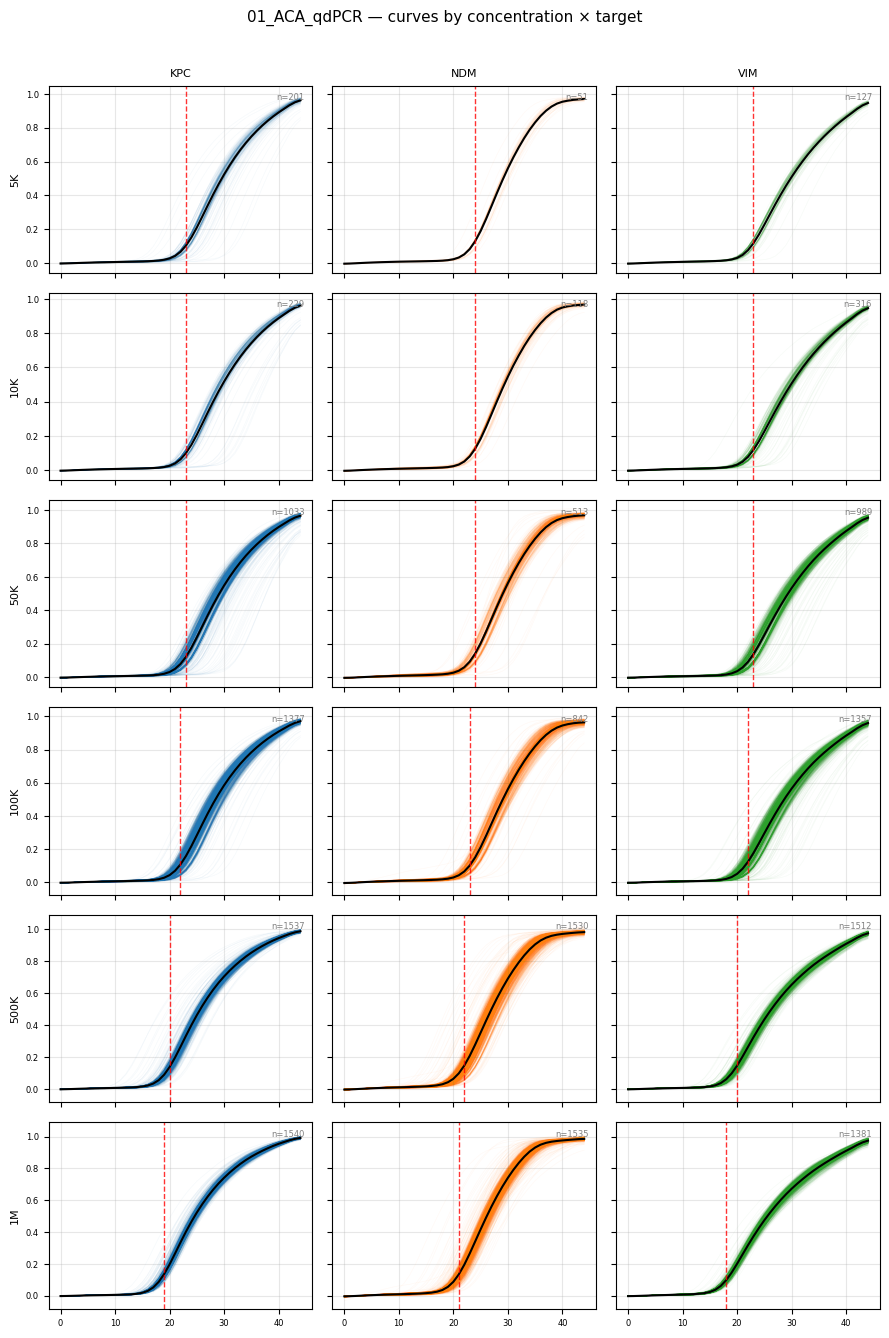

In [7]:
def plot_curve_grid(ori, labels, concentration, t_axis=None,
                    title='', max_conc_cols=MAX_CONC_COLS,
                    curve_alpha=CURVE_ALPHA, figsize_per_cell=(3.0, 2.2)):
    """Row = concentration, column = target.
    Each cell: all individual curves (low alpha) + mean in black (alpha=1)
    + vertical line at TTP (first point where mean >= 10% of its max).
    """
    valid = ~np.isnan(concentration)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], concentration[valid]
    if t_axis is None:
        t_axis = np.arange(ori.shape[1])

    unique_tgt  = sorted(np.unique(lbl_v))
    unique_conc = sorted(np.unique(con_v))

    n_rows, n_cols = len(unique_conc), len(unique_tgt)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows),
        sharex=True, sharey='row',
    )
    if n_rows == 1: axes = [axes]
    if n_cols == 1: axes = [[ax] for ax in axes]

    for r, c_val in enumerate(unique_conc):
        for c_idx, tgt in enumerate(unique_tgt):
            ax = axes[r][c_idx]
            mask = (lbl_v == tgt) & (con_v == c_val)
            subset = ori_v[mask]

            if len(subset) > 0:
                ax.plot(t_axis, subset.T, color=TARGET_COLORS.get(tgt, 'steelblue'),
                        alpha=curve_alpha, linewidth=0.5, rasterized=True)
                mean_curve = subset.mean(axis=0)
                ax.plot(t_axis, mean_curve, color='black', linewidth=1.5, alpha=1.0)

                # TTP: first index where mean >= 10% of its max
                threshold = 0.1 * mean_curve.max()
                above = np.where(mean_curve >= threshold)[0]
                if len(above) > 0:
                    ax.axvline(t_axis[above[0]], color='red', linewidth=1.0,
                               linestyle='--', alpha=0.8)

            if r == 0: ax.set_title(tgt, fontsize=8)
            if c_idx == 0: ax.set_ylabel(_conc_label(c_val), fontsize=8)
            ax.annotate(f'n={len(subset)}', xy=(0.97, 0.96), xycoords='axes fraction',
                        ha='right', va='top', fontsize=6, color='gray')
            ax.tick_params(labelsize=6)
            ax.grid(True, alpha=0.3)

    fig.suptitle(f'{title} — curves by concentration × target', y=1.01, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_curve_grid(ori, labels, conc, t_axis, title=FOLDER)

---
## Section 3 · All-in-one mean curves (target × concentration)

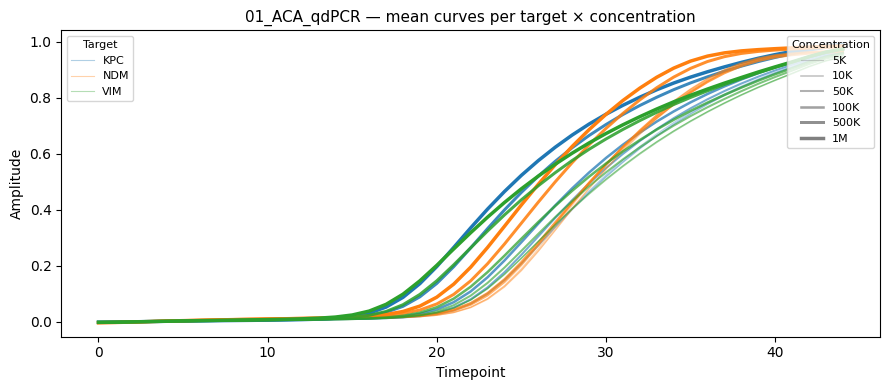

In [8]:
def plot_all_in_one(ori, labels, concentration, t_axis=None, title=''):
    """One mean curve per (target, concentration) group.
    Same target → same colour; concentration → linestyle / line width graduation.
    """
    valid = ~np.isnan(concentration)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], concentration[valid]
    if t_axis is None:
        t_axis = np.arange(ori.shape[1])

    unique_tgt  = sorted(np.unique(lbl_v))
    unique_conc = sorted(np.unique(con_v))

    # Map concentration rank → line width & alpha (low conc = thinner/lighter)
    n_c = len(unique_conc)
    lw_range  = np.linspace(0.8, 2.5, n_c)
    alp_range = np.linspace(0.35, 1.0, n_c)
    conc_rank = {c: i for i, c in enumerate(unique_conc)}

    fig, ax = plt.subplots(figsize=(9, 4))

    handles_tgt  = {}
    handles_conc = {}

    for tgt in unique_tgt:
        color = TARGET_COLORS.get(tgt, 'gray')
        for c_val in unique_conc:
            mask = (lbl_v == tgt) & (con_v == c_val)
            if mask.sum() == 0: continue
            rank = conc_rank[c_val]
            mean_curve = ori_v[mask].mean(axis=0)
            line, = ax.plot(t_axis, mean_curve, color=color,
                            linewidth=lw_range[rank], alpha=alp_range[rank])
            if tgt not in handles_tgt:
                handles_tgt[tgt] = line
            if c_val not in handles_conc:
                handles_conc[c_val] = line

    # Legend: targets (colour) + concentrations (weight)
    leg1 = ax.legend(
        handles=list(handles_tgt.values()), labels=list(handles_tgt.keys()),
        title='Target', loc='upper left', fontsize=8, title_fontsize=8
    )
    import matplotlib.lines as mlines
    conc_handles = [
        mlines.Line2D([], [], color='gray', linewidth=lw_range[conc_rank[c]], alpha=alp_range[conc_rank[c]],
                      label=_conc_label(c))
        for c in unique_conc
    ]
    ax.add_artist(leg1)
    ax.legend(handles=conc_handles, title='Concentration', loc='upper right', fontsize=8, title_fontsize=8)

    ax.set_title(f'{title} — mean curves per target × concentration', fontsize=11)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Amplitude')
    plt.tight_layout()
    plt.show()


plot_all_in_one(ori, labels, conc, t_axis, title=FOLDER)

---
## Section 4 · Exploratory analysis

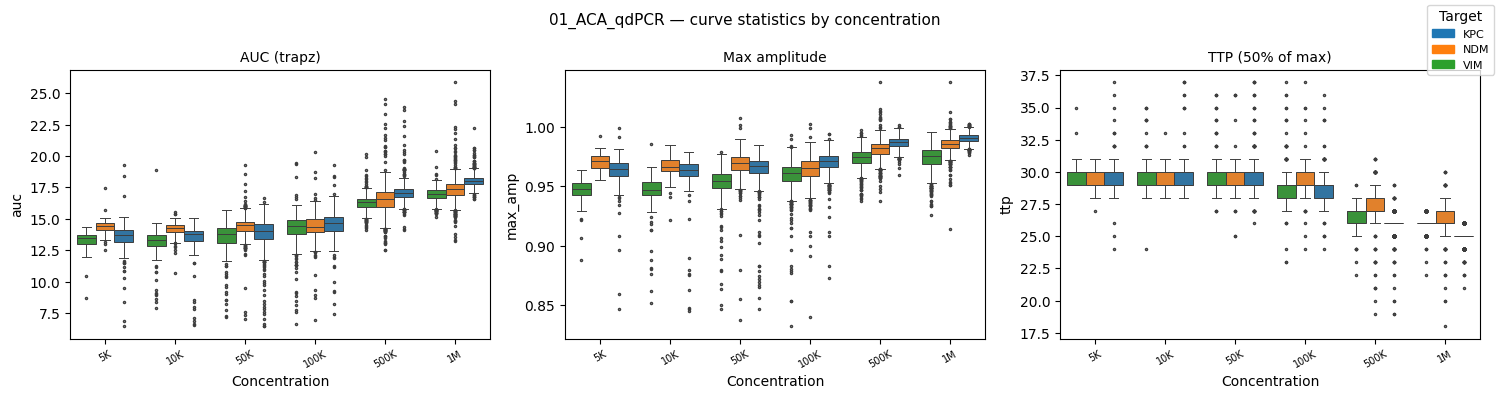

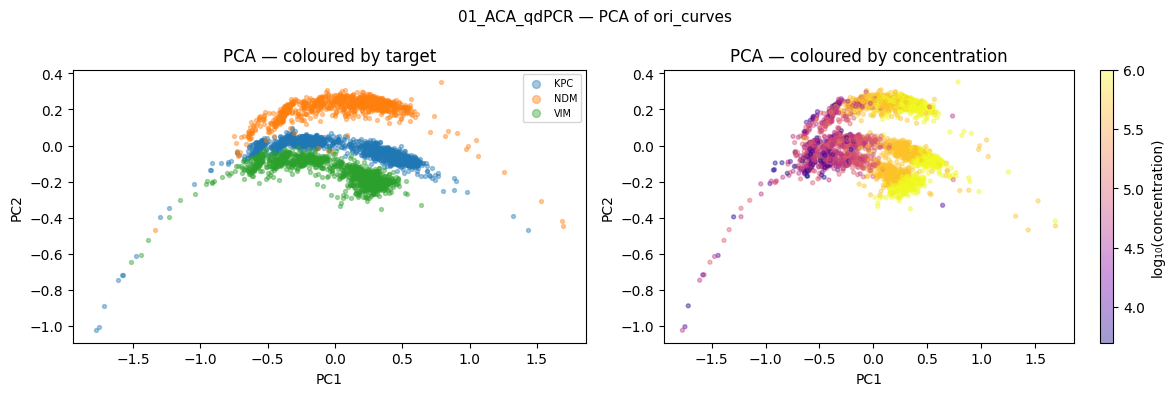

In [9]:
def compute_curve_stats(ori, labels, concentration):
    """Per-curve: AUC (trapz), max amplitude, TTP (first index above 50% of max).
    Returns a DataFrame with columns: target, concentration, auc, max_amp, ttp.
    """
    rows = []
    T = ori.shape[1]
    for i in range(len(ori)):
        curve = ori[i]
        auc   = np.trapz(curve)
        mx    = curve.max()
        above = np.where(curve >= 0.5 * mx)[0]
        ttp   = above[0] if len(above) > 0 else T
        rows.append(dict(
            target=labels[i],
            concentration=concentration[i],
            conc_label=_conc_label(concentration[i]) if not np.isnan(concentration[i]) else 'NaN',
            auc=auc,
            max_amp=mx,
            ttp=ttp,
        ))
    df = pd.DataFrame(rows)
    df = df[~np.isnan(df['concentration'])]   # drop NaN concentration rows
    return df


def plot_curve_stats(stats_df, title=''):
    """Boxplots of AUC, max amplitude, and TTP per target × concentration."""
    metrics = [('auc', 'AUC (trapz)'), ('max_amp', 'Max amplitude'), ('ttp', 'TTP (50% of max)')]
    unique_tgt = sorted(stats_df['target'].unique())
    palette = {t: TARGET_COLORS.get(t, 'gray') for t in unique_tgt}

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))

    # Sort concentrations numerically for x-axis
    conc_order = [_conc_label(c) for c in sorted(stats_df['concentration'].unique())]

    for ax, (col, label) in zip(axes, metrics):
        sns.boxplot(data=stats_df, x='conc_label', y=col, hue='target',
                    order=conc_order, palette=palette, ax=ax,
                    linewidth=0.7, fliersize=1.5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Concentration')
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.get_legend().remove()

    # Shared legend
    handles = [plt.Rectangle((0,0),1,1, color=palette[t]) for t in unique_tgt]
    fig.legend(handles, unique_tgt, title='Target', loc='upper right', fontsize=8)
    fig.suptitle(f'{title} — curve statistics by concentration', fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_pca(ori, labels, concentration, t_axis=None, title='', n_subsample=3000):
    """PCA of raw curves. Colour = target, marker size ∝ log(concentration)."""
    valid = ~np.isnan(concentration)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], concentration[valid]

    # Subsample if large
    if len(ori_v) > n_subsample:
        idx = np.random.choice(len(ori_v), n_subsample, replace=False)
        ori_v, lbl_v, con_v = ori_v[idx], lbl_v[idx], con_v[idx]

    pcs = PCA(n_components=2).fit_transform(ori_v)

    # Normalise concentration to marker size [20, 120]
    log_c  = np.log10(np.maximum(con_v, 1))
    s_norm = 20 + 100 * (log_c - log_c.min()) / (log_c.max() - log_c.min() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: colour by target
    for tgt in sorted(np.unique(lbl_v)):
        m = lbl_v == tgt
        axes[0].scatter(pcs[m, 0], pcs[m, 1], c=[TARGET_COLORS.get(tgt, 'gray')],
                        s=8, alpha=0.4, label=tgt, rasterized=True)
    axes[0].set_title('PCA — coloured by target')
    axes[0].legend(fontsize=7, markerscale=2)

    # Right: colour by log concentration
    sc = axes[1].scatter(pcs[:, 0], pcs[:, 1], c=np.log10(con_v),
                         cmap='plasma', s=8, alpha=0.4, rasterized=True)
    plt.colorbar(sc, ax=axes[1], label='log₁₀(concentration)')
    axes[1].set_title('PCA — coloured by concentration')

    for ax in axes:
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')

    fig.suptitle(f'{title} — PCA of ori_curves', fontsize=11)
    plt.tight_layout()
    plt.show()


stats = compute_curve_stats(ori, labels, conc)
plot_curve_stats(stats, FOLDER)
plot_pca(ori, labels, conc, t_axis, FOLDER)

---
## Section 5 · Misclassification by concentration

Loads saved classification results and reconstructs per-sample fold assignments to link each test prediction back to its concentration value.

In [10]:
def load_results(folder, lab_folder=LAB_FOLDER, result_jl=RESULT_JL):
    """Load classification_performances.joblib for *folder*.
    Returns the inner results dict for the first available curve_type key,
    or None if the file does not exist.
    """
    p = Path(lab_folder) / folder / result_jl
    if not p.exists():
        print(f'[!] Results not found: {p}')
        return None
    return joblib.load(p)


def _get_res_entry(all_results, outlier_filter=None):
    """Navigate the nested results dict to the per-filter entry.
    
    Structure: all_results[curve_type_key][mode_key][outlier_filter]
    Returns (res_entry, curve_type_key, mode_key) or (None, None, None).
    """
    for ct_key, ct_val in all_results.items():
        if not isinstance(ct_val, dict): continue
        for mode_key, mode_val in ct_val.items():
            if not isinstance(mode_val, dict): continue
            if outlier_filter in mode_val:
                return mode_val[outlier_filter], ct_key, mode_key
    return None, None, None


def _reconstruct_fold_conc(labels, concentration, n_splits=N_SPLITS, outlier_filter=None, features_df=None):
    """Reconstruct test-fold sample indices using the same StratifiedKFold used during training.
    
    Returns list of concentration arrays (one per fold), aligned with y_trues_ / y_preds_.
    """
    # Apply outlier filter mask
    if outlier_filter is not None and features_df is not None and outlier_filter in features_df.columns:
        mask = (features_df[outlier_filter] == 1).fillna(False).values
    else:
        mask = np.ones(len(labels), dtype=bool)

    lbl_f = labels[mask]
    con_f = concentration[mask]

    le = LabelEncoder()
    y_enc = le.fit_transform(lbl_f)

    min_class = np.unique(y_enc, return_counts=True)[1].min()
    actual_splits = min(n_splits, min_class)

    splitter = StratifiedKFold(n_splits=actual_splits, shuffle=True, random_state=0)
    fold_concs = []
    fold_labels = []
    for _, test_idx in splitter.split(np.zeros(len(y_enc)), y_enc):
        fold_concs.append(con_f[test_idx])
        fold_labels.append(le.inverse_transform(y_enc[test_idx]))
    return fold_concs, fold_labels, le


def build_prediction_df(res_entry, model_key, fold_concs, fold_labels, le):
    """Concatenate per-fold predictions into a single DataFrame with concentration.
    Columns: true_label, pred_label, concentration, correct.
    """
    pred_key = f'y_preds_{model_key}_'
    if pred_key not in res_entry:
        # Try config lookup
        for pk, _, _ in [config.MODEL_KEY_MAP.get(model_key, (None,)*3)]:
            if pk and pk in res_entry:
                pred_key = pk
                break
        else:
            print(f'[!] Key {pred_key!r} not found in results. Available: {[k for k in res_entry if "preds" in k][:6]}')
            return None

    rows = []
    n_folds = min(len(res_entry['y_trues_']), len(fold_concs))
    for fi in range(n_folds):
        y_true = res_entry['y_trues_'][fi]
        y_pred = res_entry[pred_key][fi]
        conc_f = fold_concs[fi]
        lbl_f  = fold_labels[fi]

        # Decode integer labels → strings if needed
        if isinstance(y_true[0], (int, np.integer)):
            true_strs = le.inverse_transform(y_true)
            pred_strs = le.inverse_transform(y_pred)
        else:
            true_strs, pred_strs = np.array(y_true), np.array(y_pred)

        for j in range(min(len(true_strs), len(conc_f))):
            rows.append(dict(
                true_label=true_strs[j],
                pred_label=pred_strs[j],
                concentration=conc_f[j],
                correct=(true_strs[j] == pred_strs[j]),
                fold=fi,
            ))
    return pd.DataFrame(rows)


def plot_misclassification_by_concentration(
        pred_df, title='', model_key=''):
    """Two panels:
    Left  — accuracy per target × concentration (line plot).
    Right — confusion matrix where rows = (target, conc) and cols = predicted target.
    """
    if pred_df is None or pred_df.empty:
        print('[!] No prediction data available.'); return

    valid = pred_df[~np.isnan(pred_df['concentration'])].copy()
    valid['conc_label'] = valid['concentration'].map(_conc_label)
    unique_tgt  = sorted(valid['true_label'].unique())
    unique_conc = sorted(valid['concentration'].unique())
    conc_lbls   = [_conc_label(c) for c in unique_conc]

    # ── Panel 1: accuracy per target × concentration ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    for tgt in unique_tgt:
        accs = []
        for c in unique_conc:
            sub = valid[(valid['true_label'] == tgt) & (valid['concentration'] == c)]
            accs.append(sub['correct'].mean() if len(sub) > 0 else np.nan)
        color = TARGET_COLORS.get(tgt, 'gray')
        ax.plot(conc_lbls, accs, marker='o', color=color, label=tgt, linewidth=1.5)

    ax.set_xlabel('Concentration')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('Accuracy per target × concentration')
    ax.legend(fontsize=8, title='Target')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.axhline(1 / len(unique_tgt), color='gray', linestyle='--', linewidth=0.8, label='Chance')
    ax.grid(axis='y', alpha=0.3)

    # ── Panel 2: extended confusion matrix ────────────────────────────────────
    ax = axes[1]
    row_labels = [(tgt, _conc_label(c)) for tgt in unique_tgt for c in unique_conc]
    col_labels = unique_tgt

    mat = np.zeros((len(row_labels), len(col_labels)))
    for ri, (tgt, clbl) in enumerate(row_labels):
        sub = valid[(valid['true_label'] == tgt) & (valid['conc_label'] == clbl)]
        if len(sub) == 0: continue
        for ci, pred_tgt in enumerate(col_labels):
            mat[ri, ci] = (sub['pred_label'] == pred_tgt).sum() / len(sub)

    im = ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Fraction')

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels([f'{t} / {c}' for t, c in row_labels], fontsize=6)
    ax.set_xlabel('Predicted target')
    ax.set_ylabel('True (target / concentration)')
    ax.set_title('Confusion: true(target,conc) → predicted target')

    # Diagonal markers for correct cells
    for ri, (tgt, _) in enumerate(row_labels):
        if tgt in col_labels:
            ci = col_labels.index(tgt)
            ax.add_patch(plt.Rectangle((ci - 0.5, ri - 0.5), 1, 1,
                                        fill=False, edgecolor='black', lw=0.8))

    fig.suptitle(f'{title} — {model_key} misclassification by concentration', fontsize=11)
    plt.tight_layout()
    plt.show()

Using results: curve_type='Ori Curves', mode='Native', filter=None
Reconstructed 5 folds
Prediction df: 16188 rows, overall accuracy: 0.994


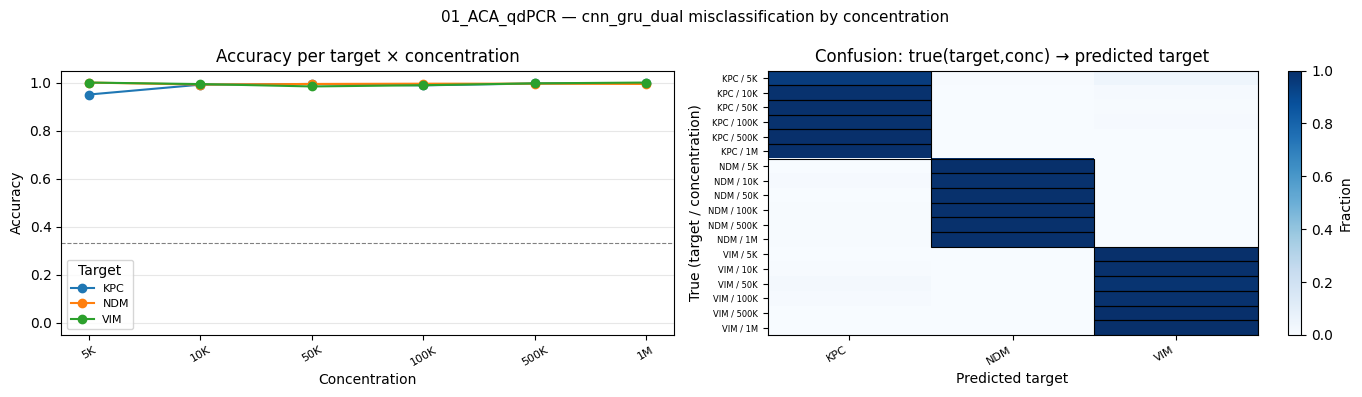

In [11]:
all_results = load_results(FOLDER)

if all_results is not None:
    res_entry, ct_key, mode_key = _get_res_entry(all_results, OUTLIER_FILTER)
    if res_entry is None:
        print(f'[!] No entry for filter={OUTLIER_FILTER!r}. Available filters:')
        for ct, ct_v in all_results.items():
            if isinstance(ct_v, dict):
                for mk, mv in ct_v.items():
                    if isinstance(mv, dict):
                        print(f'  [{ct}][{mk}]: {list(mv.keys())}')
    else:
        print(f'Using results: curve_type={ct_key!r}, mode={mode_key!r}, filter={OUTLIER_FILTER!r}')
        fold_concs, fold_labels, le = _reconstruct_fold_conc(labels, conc, N_SPLITS, OUTLIER_FILTER)
        print(f'Reconstructed {len(fold_concs)} folds')
        pred_df = build_prediction_df(res_entry, MODEL_KEY, fold_concs, fold_labels, le)
        if pred_df is not None:
            print(f'Prediction df: {len(pred_df)} rows, overall accuracy: {pred_df["correct"].mean():.3f}')
            plot_misclassification_by_concentration(pred_df, FOLDER, MODEL_KEY)

---
## Section 6 · Kinetic feature correlation

In [12]:
def _kinetic_feature_cols(kf_df):
    """Return only the true kinetic feature columns, dropping outlier-filter flags."""
    exclude_keywords = ('label', 'knn_top', 'msc_', 'amf_', 'cnn_ae_', 'lstm_ae_')
    return [c for c in kf_df.select_dtypes(include='number').columns
            if not any(k in c for k in exclude_keywords)]


def plot_kinetic_feature_correlations(kf_df, labels, concentration,
                                      group_by='concentration',
                                      top_n=12, title=''):
    """Visualise the relationship between kinetic features and concentration or target.

    group_by='concentration' : ranks features by |Pearson r| with log10(concentration).
    group_by='target'        : ranks features by one-way ANOVA F-statistic across targets.

    Two panels are shown:
      Left  — horizontal bar chart of the top_n ranked features.
      Right — violin/strip grid for the top 6 of those features.
    """
    from scipy import stats as sps

    valid = ~np.isnan(concentration)
    kf_v   = kf_df.loc[valid].reset_index(drop=True)
    lbl_v  = labels[valid]
    con_v  = concentration[valid]
    log_c  = np.log10(con_v)

    feat_cols = _kinetic_feature_cols(kf_v)
    kf_vals   = kf_v[feat_cols].copy()

    # ── Rank features ─────────────────────────────────────────────────────────
    scores = {}
    if group_by == 'concentration':
        for col in feat_cols:
            x = kf_vals[col].values
            m = np.isfinite(x) & np.isfinite(log_c)
            if m.sum() < 10: continue
            r, _ = sps.pearsonr(x[m], log_c[m])
            scores[col] = r                          # keep sign for direction
        score_label = 'Pearson r  (feature vs log₁₀ conc)'
        sorted_feats = sorted(scores, key=lambda c: abs(scores[c]), reverse=True)[:top_n]

    else:  # group_by == 'target'
        unique_tgt = np.unique(lbl_v)
        for col in feat_cols:
            groups = [kf_vals.loc[lbl_v == t, col].dropna().values for t in unique_tgt]
            groups = [g for g in groups if len(g) >= 3]
            if len(groups) < 2: continue
            f, _ = sps.f_oneway(*groups)
            scores[col] = f
        score_label = 'ANOVA F-statistic  (feature vs target)'
        sorted_feats = sorted(scores, key=lambda c: scores[c], reverse=True)[:top_n]

    # ── Panel 1: ranked bar chart ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, top_n * 0.38 + 1)),
                              gridspec_kw={'width_ratios': [1, 1.8]})

    vals  = [scores[f] for f in sorted_feats]
    colors_bar = ['#d62728' if v < 0 else '#1f77b4' for v in vals]
    axes[0].barh(range(len(sorted_feats)), vals, color=colors_bar, alpha=0.8)
    axes[0].set_yticks(range(len(sorted_feats)))
    axes[0].set_yticklabels(sorted_feats, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].axvline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel(score_label, fontsize=8)
    axes[0].set_title(f'Top {top_n} features', fontsize=10)
    axes[0].grid(axis='x', alpha=0.3)

    # ── Panel 2: violin/scatter for top 6 ─────────────────────────────────────
    show_feats = sorted_feats[:6]
    n_show = len(show_feats)
    ax2 = axes[1]
    ax2.axis('off')
    sub_fig, sub_axes = plt.subplots(2, 3, figsize=(12, 6))
    sub_axes = sub_axes.flatten()

    for i, feat in enumerate(show_feats):
        ax = sub_axes[i]
        feat_vals = kf_v[feat].values

        if group_by == 'concentration':
            unique_conc = sorted(np.unique(con_v))
            groups_data = [feat_vals[(con_v == c) & np.isfinite(feat_vals)] for c in unique_conc]
            ax.violinplot(groups_data, positions=range(len(unique_conc)), showmedians=True)
            ax.set_xticks(range(len(unique_conc)))
            ax.set_xticklabels([_conc_label(c) for c in unique_conc], rotation=30, fontsize=6)
            ax.set_title(f'{feat}\nr={scores[feat]:.2f}', fontsize=7)

        else:
            unique_tgt = sorted(np.unique(lbl_v))
            groups_data = [feat_vals[lbl_v == t] for t in unique_tgt]
            parts = ax.violinplot(groups_data, positions=range(len(unique_tgt)), showmedians=True)
            for j, pc in enumerate(parts['bodies']):
                tgt = unique_tgt[j]
                pc.set_facecolor(TARGET_COLORS.get(tgt, 'steelblue'))
                pc.set_alpha(0.7)
            ax.set_xticks(range(len(unique_tgt)))
            ax.set_xticklabels(unique_tgt, rotation=30, fontsize=6)
            ax.set_title(f'{feat}\nF={scores[feat]:.1f}', fontsize=7)

        ax.set_ylabel(feat, fontsize=6)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(labelsize=6)

    for i in range(n_show, len(sub_axes)):
        sub_axes[i].axis('off')

    sub_fig.suptitle(f'{title} — top feature distributions by {group_by}', fontsize=10)
    sub_fig.tight_layout()

    plt.figure(fig.number)
    fig.suptitle(f'{title} — kinetic feature correlation with {group_by}', fontsize=11)
    axes[0].figure.tight_layout()
    plt.show()
    plt.figure(sub_fig.number)
    plt.show()

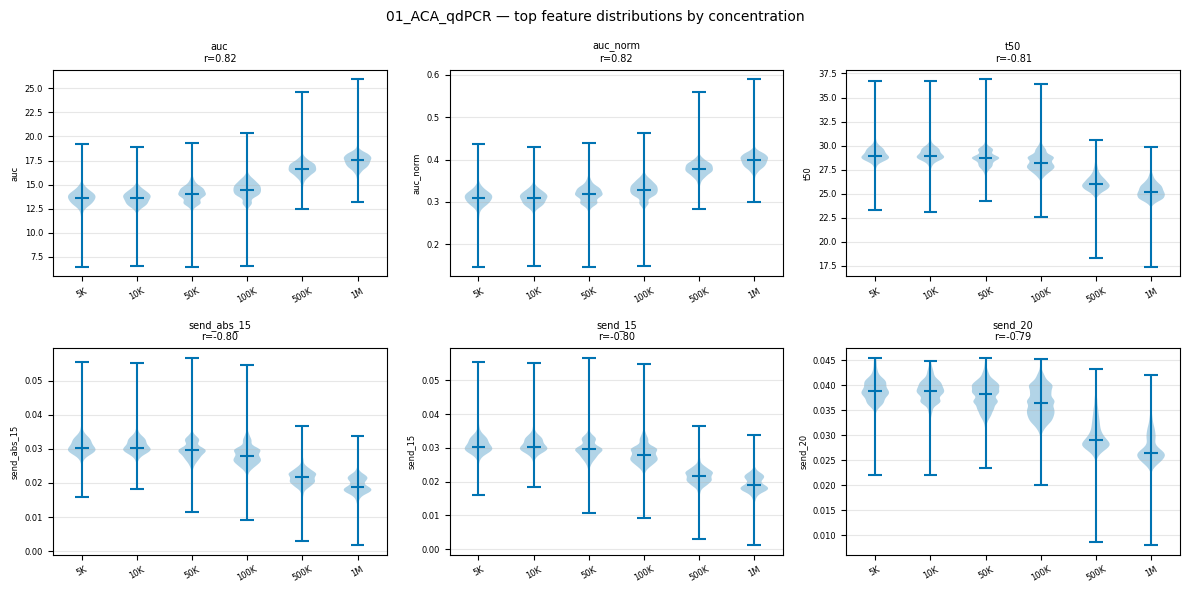

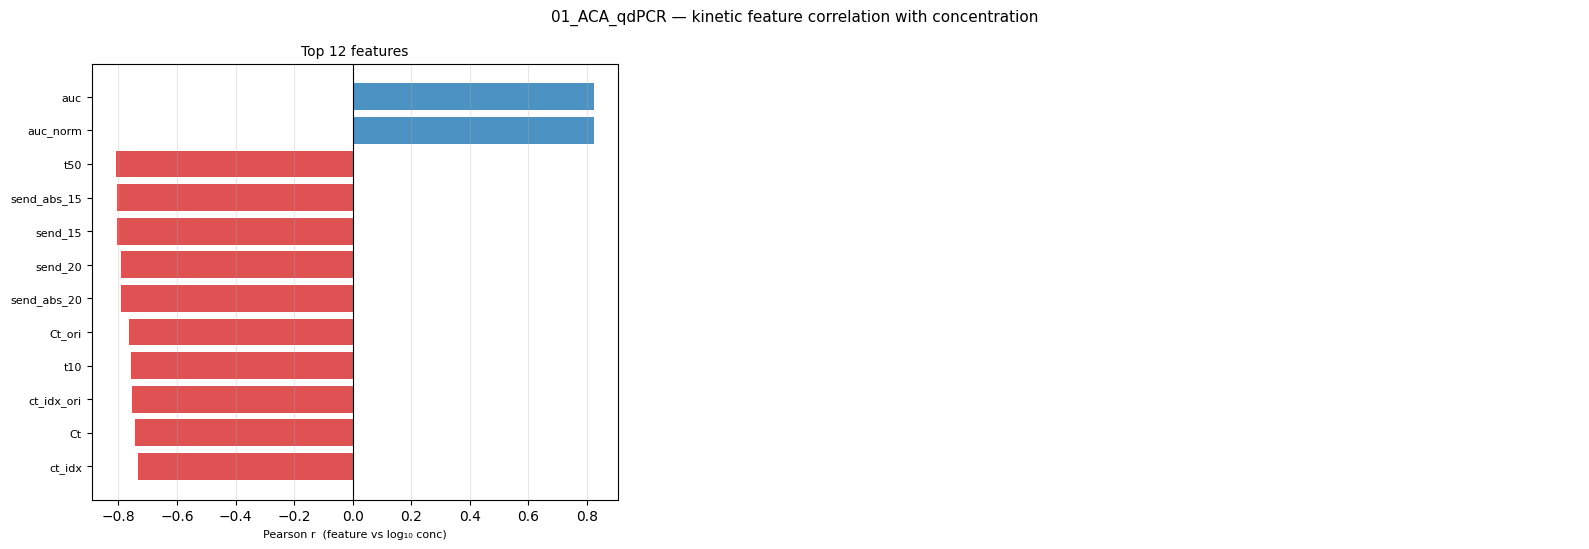

<Figure size 640x480 with 0 Axes>

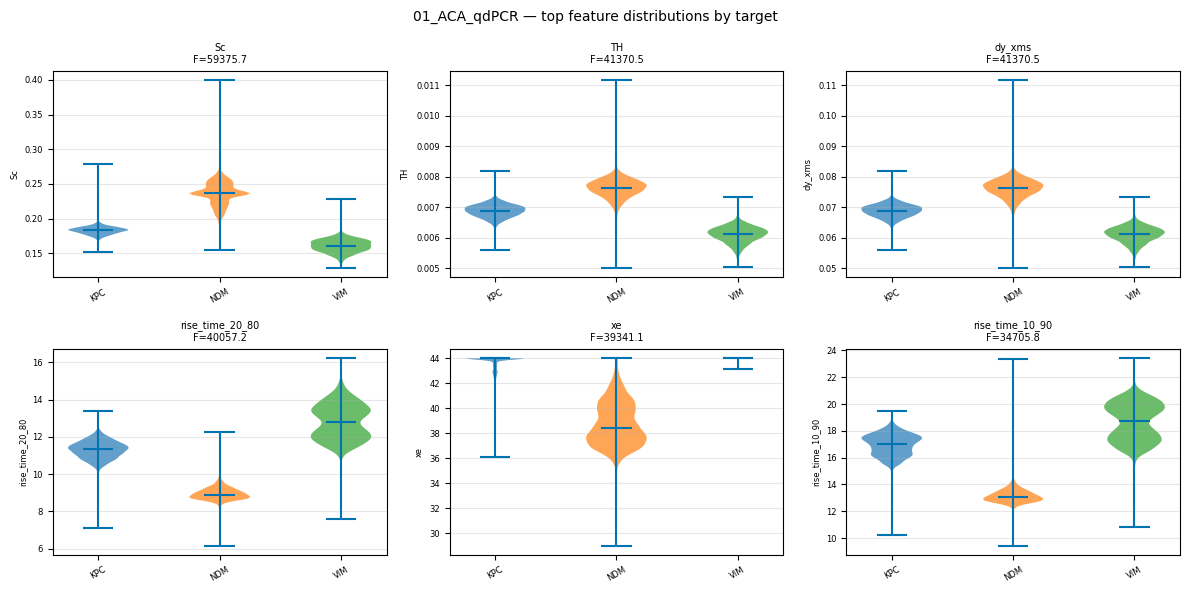

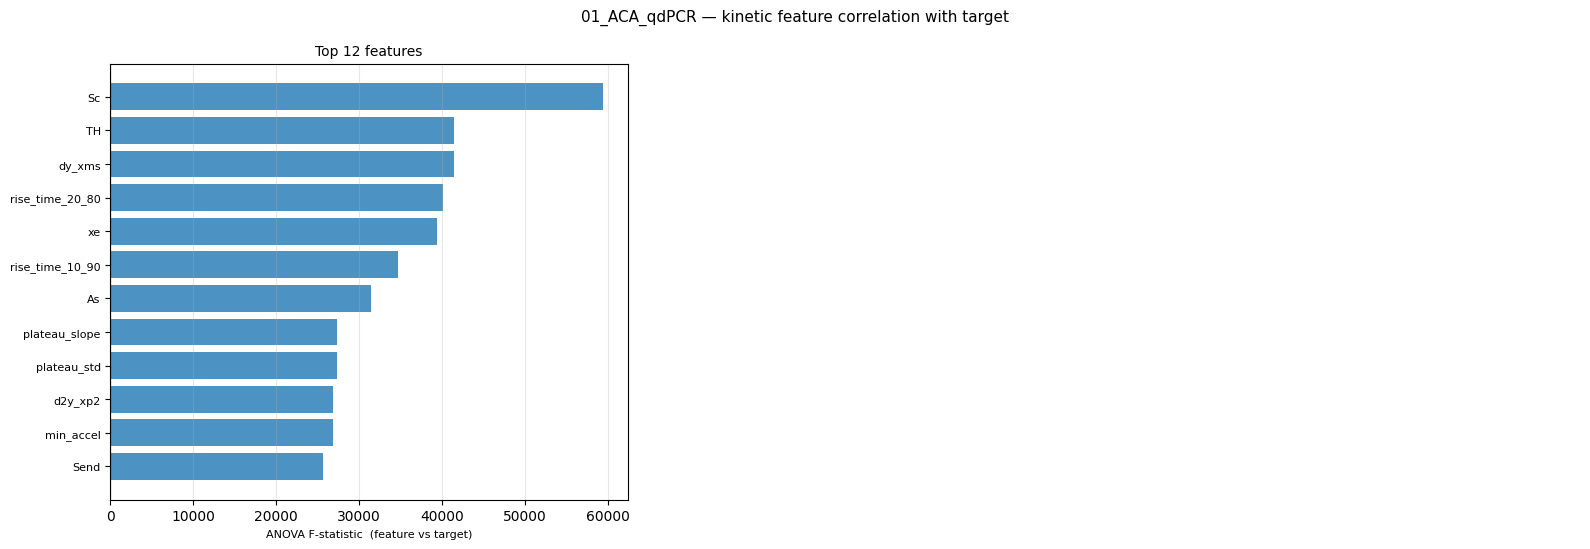

<Figure size 640x480 with 0 Axes>

In [13]:
if kf is not None:
    plot_kinetic_feature_correlations(kf, labels, conc, group_by='concentration', title=FOLDER)
    plot_kinetic_feature_correlations(kf, labels, conc, group_by='target', title=FOLDER)
else:
    print('[!] No kinetic features found in this joblib.')

---
## (Optional) Multi-folder comparison

Uncomment and run to iterate over all concentration-having folders.

In [14]:
# available = list_available_folders()['folder'].tolist()
# for folder in available:
#     print(f"\n{'='*60}\n{folder}\n{'='*60}")
#     d = load_folder_data(folder)
#     _assign_target_colors(d['labels'])
#     plot_distribution_table(d['labels'], d['concentration'], folder)
#     plot_all_in_one(d['ori_curves'], d['labels'], d['concentration'],
#                     d['timestamps'], title=folder)

---
## Section 7 · Classification — Single-Task vs Multi-Task

Grouped bar chart of accuracy (mean ± std across folds) for every ST/MTL model pair
found in the loaded results. The Δ annotation (green = MTL better, red = worse)
shows the net impact of adding the concentration regression head.

In [15]:
from IPython.display import display

_DEFAULT_MODELS = ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']

_MODEL_LABELS = {
    'cnn':            'CNN',
    'lstm':           'LSTM',
    'gru':            'GRU',
    'rnn':            'RNN',
    'transformer':    'Transformer',
    'cnn_gru_dual':   'CNN+GRU',
    'cnn_trans_dual': 'CNN+Tr',
    'cnn_lstm_dual':  'CNN+LSTM',
}


def plot_stmtl_comparison(res_entry, title='', models=None):
    """4-way grouped bar chart: ST / ST+SupCon / MTL / MTL+SupCon per model."""
    if res_entry is None:
        print('[!] No results loaded — run Section 5 first.'); return
    if models is None:
        models = _DEFAULT_MODELS

    def _fold_accs(pk):
        return [np.mean(np.array(yt) == np.array(yp)) * 100
                for yt, yp in zip(res_entry.get('y_trues_', []), res_entry.get(pk, []))]

    def _stats(key):
        pk = config.MODEL_KEY_MAP.get(key, (None,))[0]
        if not pk or pk not in res_entry:
            return None, None
        a = _fold_accs(pk)
        return (np.mean(a), np.std(a)) if a else (None, None)

    rows = []
    for base in models:
        label = _MODEL_LABELS.get(base, base)
        st_m,    st_s    = _stats(base)
        sc_m,    sc_s    = _stats(base + '_supcon')
        mtl_m,   mtl_s   = _stats(base + '_mtl')
        scmtl_m, scmtl_s = _stats(base + '_supcon_mtl')
        if st_m is None:
            continue
        rows.append(dict(name=label,
                         st=(st_m, st_s), sc=(sc_m, sc_s),
                         mtl=(mtl_m, mtl_s), sc_mtl=(scmtl_m, scmtl_s)))

    if not rows:
        print('[!] No models found in results.'); return

    COLOR_ST     = '#2a78d6'
    COLOR_SC     = '#e07b39'
    COLOR_MTL    = '#1baf7a'
    COLOR_SC_MTL = '#9055a2'

    n, w = len(rows), 0.2
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * w
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(9, n * 1.8), 5.5))

    def _draw(vals, offset, label, color):
        xi = np.array([i for i, (m, _s) in enumerate(vals) if m is not None])
        mi = np.array([m for m, _s in vals if m is not None])
        si = np.array([s for _m, s in vals if _m is not None])
        if not len(xi):
            return
        bars = ax.bar(xi + offset, mi, w, yerr=si, color=color, alpha=0.85,
                      label=label, capsize=3, error_kw={'linewidth': 1, 'alpha': 0.6})
        for bar, mv, sv in zip(bars, mi, si):
            ax.text(bar.get_x() + w / 2, mv + sv + 0.08, f"{mv:.2f}",
                    ha='center', va='bottom', fontsize=7.5, color='#52514e', fontweight='bold')

    _draw([r['st']     for r in rows], offsets[0], 'Single-Task',          COLOR_ST)
    _draw([r['sc']     for r in rows], offsets[1], 'Single-Task + SupCon', COLOR_SC)
    _draw([r['mtl']    for r in rows], offsets[2], 'Multi-Task',           COLOR_MTL)
    _draw([r['sc_mtl'] for r in rows], offsets[3], 'Multi-Task + SupCon',  COLOR_SC_MTL)

    all_means = [r[k][0] for r in rows for k in ('st', 'sc', 'mtl', 'sc_mtl') if r[k][0] is not None]
    ax.set_ylim(max(0, min(all_means) - 3), min(100, max(all_means) + 3))
    ax.set_xticks(x)
    ax.set_xticklabels([r['name'] for r in rows], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linewidth=0.8)
    ax.set_title(f"{title} — ST / ST+SupCon / MTL / MTL+SupCon", fontsize=11)
    plt.tight_layout()
    plt.show()

    def _fmt(m, s): return f"{m:.2f} ± {s:.2f}" if m is not None else '—'
    df = pd.DataFrame([{
        'Model':          r['name'],
        'ST (%)':         _fmt(*r['st']),
        'ST+SupCon (%)':  _fmt(*r['sc']),
        'MTL (%)':        _fmt(*r['mtl']),
        'MTL+SupCon (%)': _fmt(*r['sc_mtl']),
    } for r in rows])
    display(df.set_index('Model'))


---
## Section 8 · Regression Performance (MTL)

Three panels for each MTL model that has regression results stored:
- **8a** — RMSE, MAE, and R² metric bars (which model predicts concentration best?)
- **8b** — Predicted vs actual scatter in log₁₀ space (are errors systematic?)
- **8c** — Residual = log₁₀(pred/true) by concentration level (are certain bins biased?)

In [16]:
REG_SENTINEL = -1.0   # must match model_utils_mtl.py REG_SENTINEL


def collect_reg_results(res_entry):
    """Collect per-model regression arrays and aggregate metrics.

    Returns a list of dicts (one per MTL model that has reg keys in res_entry):
        model, label, rmse, mae, r2, n_valid, preds (N,), trues (N,)
    Sentinel (-1.0) values are excluded before computing any metric.
    """
    out = []
    for m_name in sorted(config._MTL_MODEL_KEYS):
        rk = f'y_reg_preds_{m_name}_'
        tk = f'y_reg_trues_{m_name}_'
        if rk not in res_entry or tk not in res_entry:
            continue
        p_folds = res_entry[rk]
        t_folds = res_entry[tk]
        if not p_folds or not t_folds:
            continue
        p_all = np.concatenate(p_folds)
        t_all = np.concatenate(t_folds)
        vm    = t_all != REG_SENTINEL
        if vm.sum() < 2:
            continue
        p, t  = p_all[vm], t_all[vm]
        rmse  = float(np.sqrt(np.mean((p - t) ** 2)))
        mae   = float(np.mean(np.abs(p - t)))
        ss    = float(np.sum((t - t.mean()) ** 2))
        r2    = 1.0 - float(np.sum((t - p) ** 2)) / ss if ss > 0 else 0.0
        out.append(dict(model=m_name,
                        label=config.MODEL_PRINT_MAP.get(m_name, m_name),
                        rmse=rmse, mae=mae, r2=r2,
                        n_valid=int(vm.sum()),
                        preds=p, trues=t))
    return out


def plot_reg_metrics(reg_data, title=''):
    """8a — Horizontal bars: RMSE & MAE (left) and R² (right) per MTL model."""
    if not reg_data:
        print('[!] No regression data — no MTL reg keys found in results.'); return

    names     = [r['label']  for r in reg_data]
    rmse_vals = [r['rmse']   for r in reg_data]
    mae_vals  = [r['mae']    for r in reg_data]
    r2_vals   = [r['r2']     for r in reg_data]
    n         = len(reg_data)
    h         = max(3.5, n * 0.55 + 1.5)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, h))
    y  = np.arange(n)
    bw = 0.35

    # ── RMSE & MAE ────────────────────────────────────────────────────────────
    ax1.barh(y + bw / 2, rmse_vals, bw, color='#2a78d6', alpha=0.85, label='RMSE')
    ax1.barh(y - bw / 2, mae_vals,  bw, color='#1baf7a', alpha=0.85, label='MAE')
    for i, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
        ax1.text(r * 1.01, i + bw / 2, f'{r:,.0f}', va='center', fontsize=7, color='#52514e')
        ax1.text(m * 1.01, i - bw / 2, f'{m:,.0f}', va='center', fontsize=7, color='#52514e')
    ax1.set_yticks(y); ax1.set_yticklabels(names, fontsize=9)
    ax1.invert_yaxis()
    ax1.legend(fontsize=9)
    ax1.set_xlabel('Error (original concentration scale)')
    ax1.set_title('RMSE & MAE per MTL model')
    ax1.grid(axis='x', alpha=0.3, linewidth=0.8)
    ax1.axvline(0, color='#c3c2b7', linewidth=1)

    # ── R² ────────────────────────────────────────────────────────────────────
    ax2.barh(y, r2_vals, 0.5, color='#4a3aa7', alpha=0.85)
    for i, v in enumerate(r2_vals):
        ax2.text(max(v, 0) + 0.01, i, f'{v:.3f}', va='center', fontsize=7.5, color='#52514e')
    ax2.set_yticks(y); ax2.set_yticklabels(names, fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlim(-0.05, 1.08)
    ax2.axvline(0, color='#c3c2b7', linewidth=1)
    ax2.set_xlabel('R²')
    ax2.set_title('R² per MTL model')
    ax2.grid(axis='x', alpha=0.3, linewidth=0.8)

    fig.suptitle(f'{title} — MTL Regression Metrics (original concentration scale)', fontsize=11)
    plt.tight_layout()
    plt.show()

    df_reg = pd.DataFrame([{
        'Model':   r['label'],
        'RMSE':    f"{r['rmse']:,.1f}",
        'MAE':     f"{r['mae']:,.1f}",
        'R²':      f"{r['r2']:.4f}",
        'N valid': r['n_valid'],
    } for r in reg_data])
    display(df_reg.set_index('Model'))

In [17]:
def plot_reg_scatter(reg_data, title='', max_models=9, log10_scale=True):
    """8b — Predicted vs actual scatter, one subplot per model.

    log10_scale=True  (default): axes in log₁₀ space, matching training normalisation.
    log10_scale=False           : axes in original concentration scale.

    Points coloured by true concentration (sequential blue, light→dark = low→high).
    Red dashed identity line (y = x). Square axes so bias is immediately visible.
    """
    if not reg_data:
        print('[!] No regression data.'); return

    models = reg_data[:max_models]
    ncols  = min(3, len(models))
    nrows  = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(4.5 * ncols, 4.2 * nrows), squeeze=False)

    for i, row in enumerate(models):
        ax = axes[i // ncols][i % ncols]

        if log10_scale:
            p_plot = np.log10(np.maximum(row['preds'], 0.1))
            t_plot = np.log10(np.maximum(row['trues'], 0.1))
            xlabel, ylabel = 'True conc. (log₁₀)', 'Pred. conc. (log₁₀)'
        else:
            p_plot = row['preds']
            t_plot = row['trues']
            xlabel, ylabel = 'True concentration', 'Pred. concentration'

        sc = ax.scatter(t_plot, p_plot, s=5, alpha=0.3,
                        c=t_plot, cmap='Blues',
                        vmin=t_plot.min(), vmax=t_plot.max(),
                        rasterized=True)

        lo = min(t_plot.min(), p_plot.min())
        hi = max(t_plot.max(), p_plot.max())
        ax.plot([lo, hi], [lo, hi], color='#e34948', linewidth=1.2,
                linestyle='--', alpha=0.8)

        unique_c = sorted(np.unique(np.round(row['trues'], 0)))
        if log10_scale:
            ticks = np.log10(np.maximum(unique_c, 0.1))
        else:
            ticks = unique_c
        ax.set_xticks(ticks)
        ax.set_xticklabels([_conc_label(c) for c in unique_c], rotation=30, fontsize=6.5)
        ax.set_yticks(ticks)
        ax.set_yticklabels([_conc_label(c) for c in unique_c], fontsize=6.5)

        ax.set_title(
            f"{row['label']}\nRMSE {row['rmse']:,.0f}  MAE {row['mae']:,.0f}  R²={row['r2']:.3f}",
            fontsize=8)
        ax.set_xlabel(xlabel, fontsize=7.5)
        ax.set_ylabel(ylabel, fontsize=7.5)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(alpha=0.3, linewidth=0.8)

    for j in range(len(models), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')

    scale_label = 'log₁₀ scale' if log10_scale else 'original scale'
    fig.suptitle(f'{title} — Predicted vs actual concentration ({scale_label})', fontsize=11)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_reg_residuals(reg_data, title='', max_models=9):
    """8c — Residual = log₁₀(pred/true) per concentration bucket, one panel per model.

    A centred boxplot per concentration shows whether bias is systematic at specific
    levels (median far from 0 = model over/under-predicts that range).
    Blue fill, red median line for fast reading.
    """
    if not reg_data:
        print('[!] No regression data.'); return

    models = reg_data[:max_models]
    ncols  = min(3, len(models))
    nrows  = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(4.5 * ncols, 3.8 * nrows),
                              sharey=True, squeeze=False)

    for i, row in enumerate(models):
        ax    = axes[i // ncols][i % ncols]
        p_log = np.log10(np.maximum(row['preds'], 0.1))
        t_log = np.log10(np.maximum(row['trues'], 0.1))
        resid = p_log - t_log   # log₁₀(pred / true): 0 = perfect, +1 = 10× over

        unique_c = sorted(np.unique(np.round(row['trues'], 0)))
        groups   = [resid[np.round(row['trues'], 0) == c] for c in unique_c]
        xlabels  = [_conc_label(c) for c in unique_c]

        bp = ax.boxplot(groups, labels=xlabels, patch_artist=True,
                        medianprops=dict(color='#e34948', linewidth=2),
                        whiskerprops=dict(color='#52514e', linewidth=0.9),
                        capprops=dict(color='#52514e', linewidth=0.9),
                        flierprops=dict(marker='.', markersize=3, alpha=0.4,
                                        color='#898781'))
        for patch in bp['boxes']:
            patch.set_facecolor('#2a78d6')
            patch.set_alpha(0.30)

        ax.axhline(0, color='#c3c2b7', linewidth=1, linestyle='--')
        ax.set_title(row['label'], fontsize=9)
        ax.set_xlabel('Concentration', fontsize=8)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.grid(axis='y', alpha=0.3, linewidth=0.8)

    for r in range(nrows):
        axes[r][0].set_ylabel('log₁₀(pred / true)', fontsize=8)

    for j in range(len(models), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')

    fig.suptitle(f'{title} — Regression residuals by concentration  '
                 f'(0 = perfect; +1 = predicted 10× too high)', fontsize=11)
    plt.tight_layout()
    plt.show()

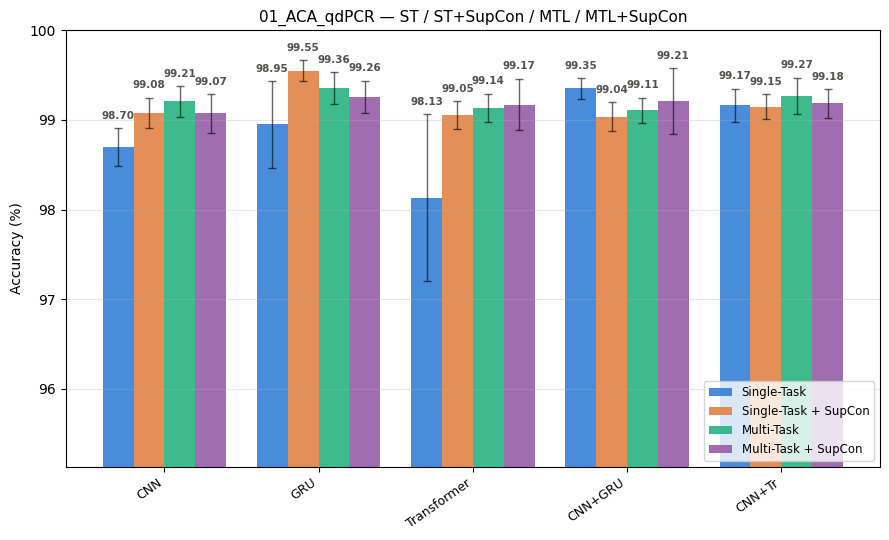

,ST (%),ST+SupCon (%),MTL (%),MTL+SupCon (%)
Model,,,,
CNN,98.70 ± 0.21,99.08 ± 0.17,99.21 ± 0.17,99.07 ± 0.22
GRU,98.95 ± 0.48,99.55 ± 0.12,99.36 ± 0.18,99.26 ± 0.18
Transformer,98.13 ± 0.93,99.05 ± 0.16,99.14 ± 0.16,99.17 ± 0.29
CNN+GRU,99.35 ± 0.12,99.04 ± 0.16,99.11 ± 0.14,99.21 ± 0.37
CNN+Tr,99.17 ± 0.18,99.15 ± 0.14,99.27 ± 0.20,99.18 ± 0.16


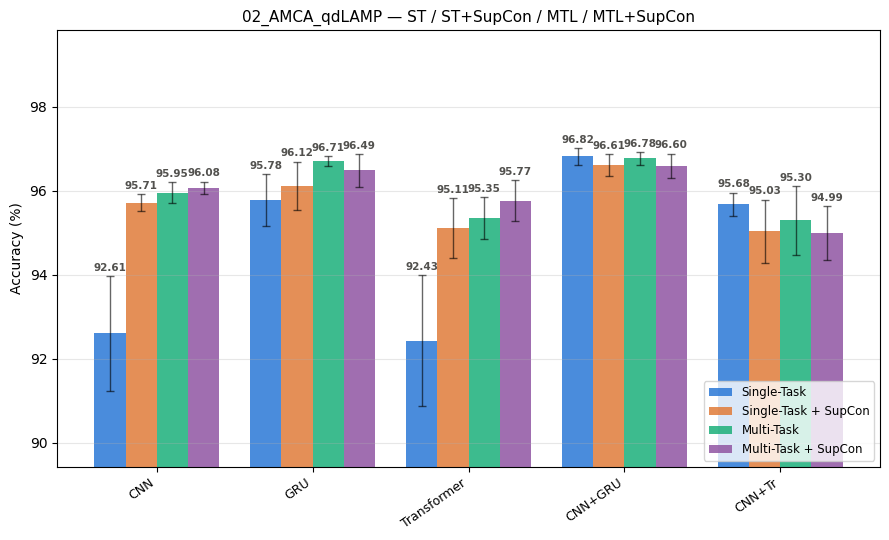

,ST (%),ST+SupCon (%),MTL (%),MTL+SupCon (%)
Model,,,,
CNN,92.61 ± 1.37,95.71 ± 0.20,95.95 ± 0.25,96.08 ± 0.14
GRU,95.78 ± 0.61,96.12 ± 0.58,96.71 ± 0.12,96.49 ± 0.38
Transformer,92.43 ± 1.56,95.11 ± 0.71,95.35 ± 0.49,95.77 ± 0.49
CNN+GRU,96.82 ± 0.20,96.61 ± 0.27,96.78 ± 0.15,96.60 ± 0.29
CNN+Tr,95.68 ± 0.28,95.03 ± 0.76,95.30 ± 0.82,94.99 ± 0.64


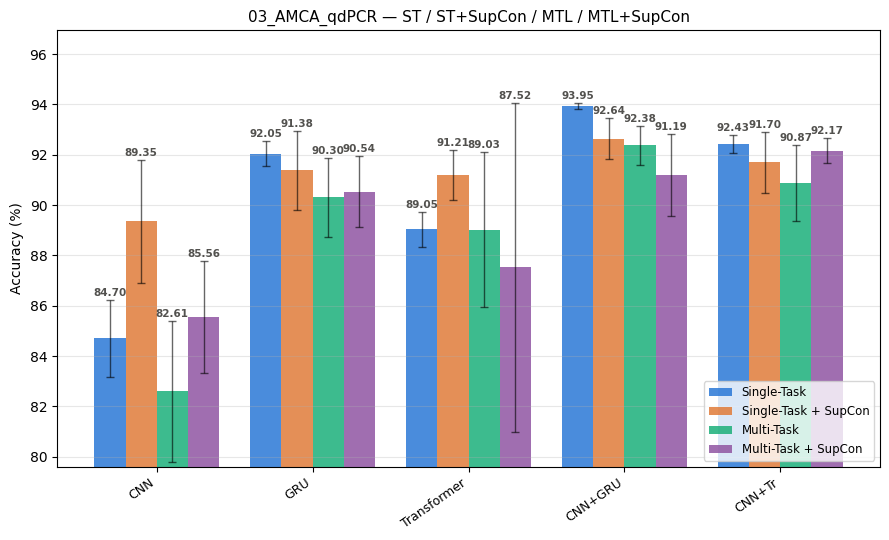

,ST (%),ST+SupCon (%),MTL (%),MTL+SupCon (%)
Model,,,,
CNN,84.70 ± 1.53,89.35 ± 2.46,82.61 ± 2.80,85.56 ± 2.23
GRU,92.05 ± 0.51,91.38 ± 1.57,90.30 ± 1.57,90.54 ± 1.42
Transformer,89.05 ± 0.70,91.21 ± 0.99,89.03 ± 3.09,87.52 ± 6.54
CNN+GRU,93.95 ± 0.12,92.64 ± 0.82,92.38 ± 0.77,91.19 ± 1.64
CNN+Tr,92.43 ± 0.35,91.70 ± 1.22,90.87 ± 1.51,92.17 ± 0.49


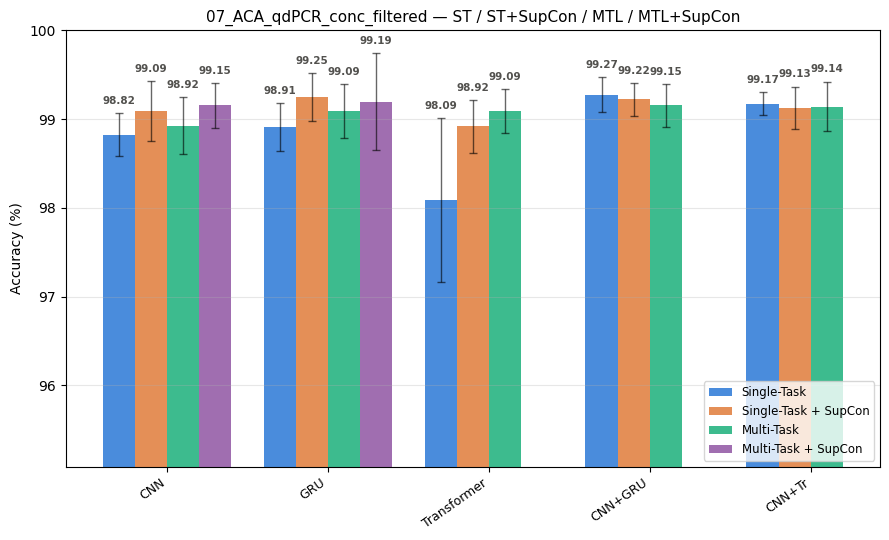

,ST (%),ST+SupCon (%),MTL (%),MTL+SupCon (%)
Model,,,,
CNN,98.82 ± 0.24,99.09 ± 0.34,98.92 ± 0.32,99.15 ± 0.25
GRU,98.91 ± 0.27,99.25 ± 0.27,99.09 ± 0.30,99.19 ± 0.55
Transformer,98.09 ± 0.92,98.92 ± 0.29,99.09 ± 0.25,—
CNN+GRU,99.27 ± 0.20,99.22 ± 0.18,99.15 ± 0.24,—
CNN+Tr,99.17 ± 0.13,99.13 ± 0.24,99.14 ± 0.28,—


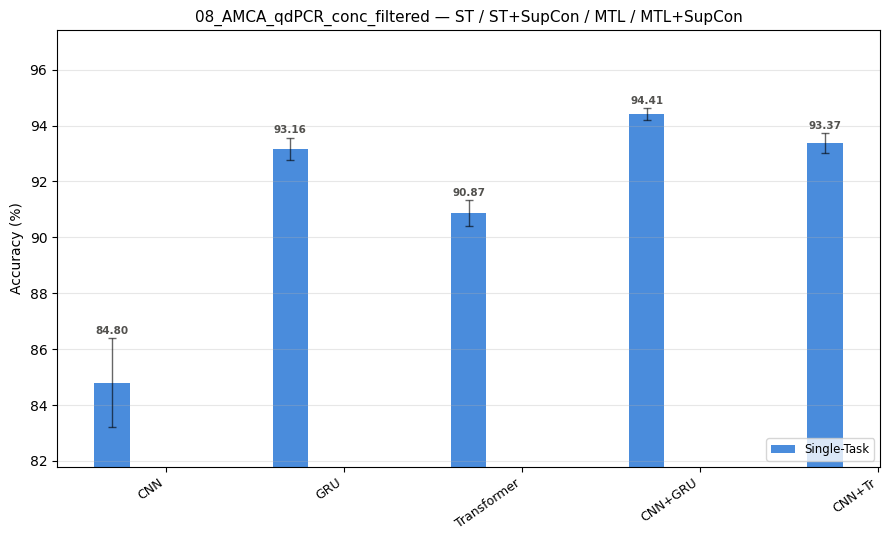

,ST (%),ST+SupCon (%),MTL (%),MTL+SupCon (%)
Model,,,,
CNN,84.80 ± 1.60,—,—,—
GRU,93.16 ± 0.41,—,—,—
Transformer,90.87 ± 0.45,—,—,—
CNN+GRU,94.41 ± 0.21,—,—,—
CNN+Tr,93.37 ± 0.36,—,—,—


In [19]:
_folders = (
    [FOLDER] if FOLDER is not None
    else sorted(f.name for f in Path(LAB_FOLDER).iterdir()
                if f.is_dir() and (f / RESULT_JL).exists())
)
_folders = ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered']

for _folder in _folders:
    _raw = load_results(_folder)
    if _raw is None:
        continue
    _res, _, _ = _get_res_entry(_raw, OUTLIER_FILTER)
    if _res is None:
        print(f'[!] {_folder}: no entry for filter={OUTLIER_FILTER!r}. Skipping.')
        continue

    reg_data = collect_reg_results(_res)

    plot_stmtl_comparison(_res, _folder)
    # plot_reg_metrics(reg_data, _folder)
    # plot_reg_scatter(reg_data, _folder)
    # plot_reg_residuals(reg_data, _folder)

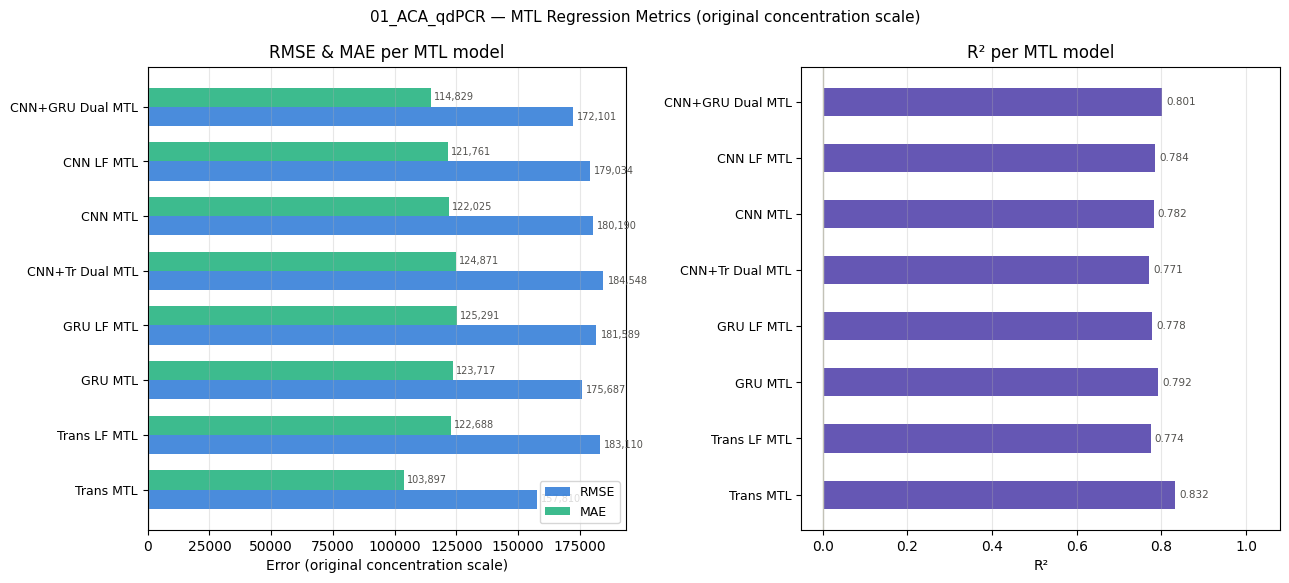

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"172,101.5","114,828.8",0.8007,16188
CNN LF MTL,"179,033.6","121,760.7",0.7844,16188
CNN MTL,"180,189.8","122,025.3",0.7816,16188
CNN+Tr Dual MTL,"184,547.6","124,871.3",0.7709,16188
GRU LF MTL,"181,589.3","125,291.2",0.7782,16188
GRU MTL,"175,687.0","123,716.6",0.7924,16188
Trans LF MTL,"183,110.2","122,687.5",0.7744,16188
Trans MTL,"157,809.7","103,897.3",0.8325,16188


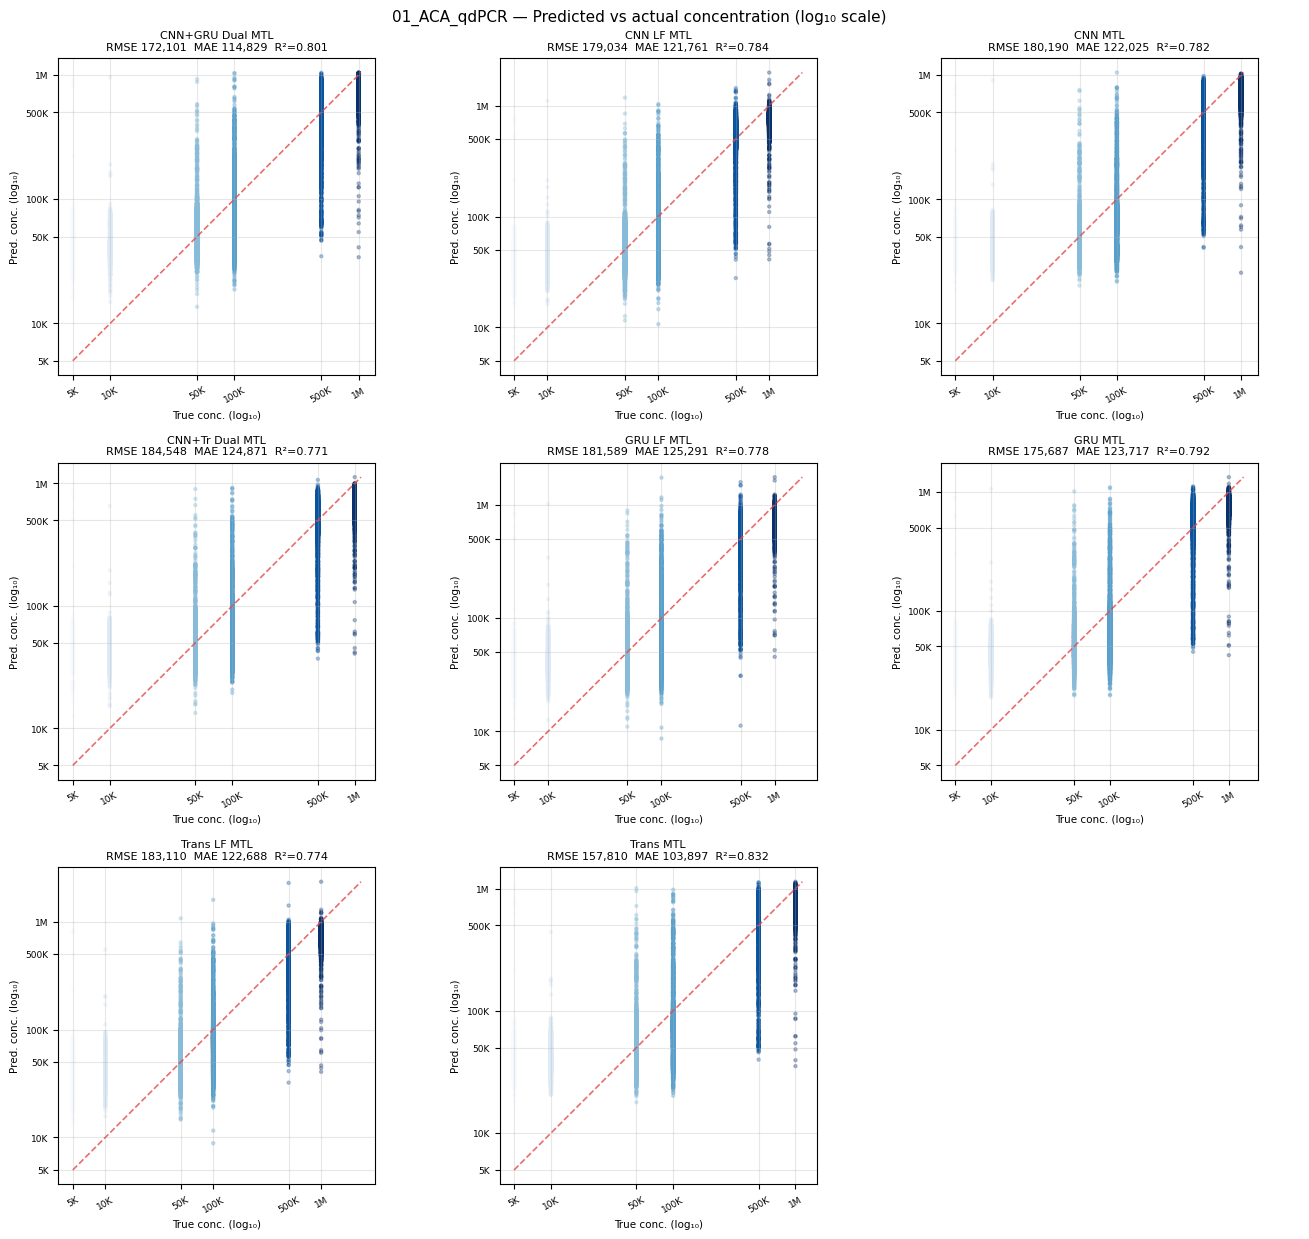

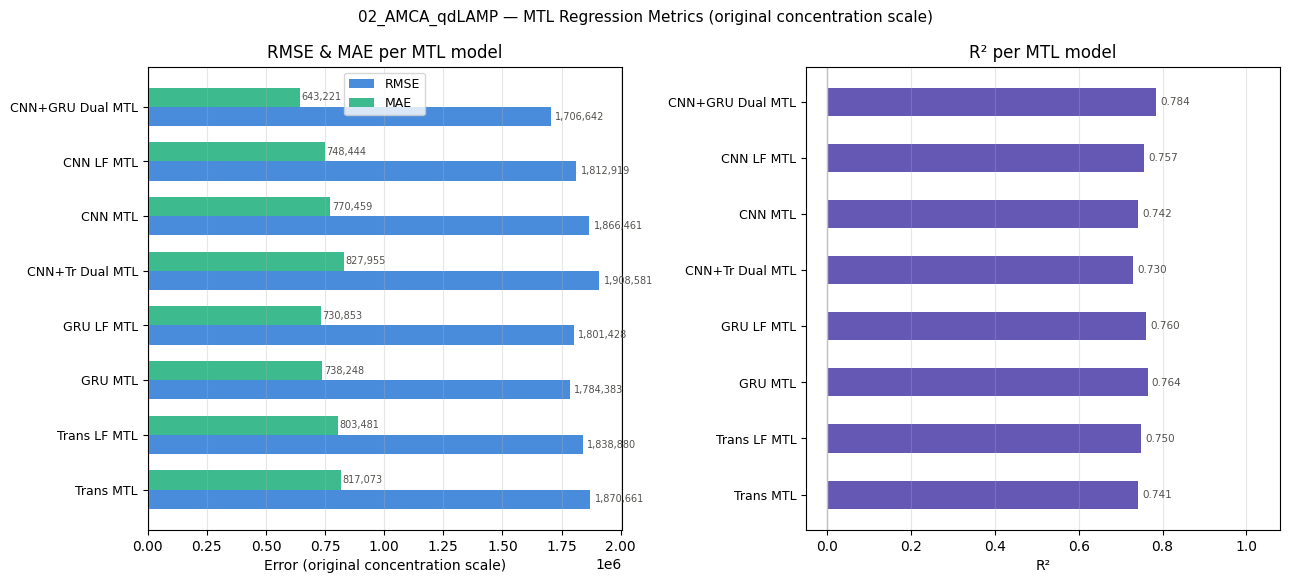

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"1,706,642.3","643,220.8",0.7844,54186
CNN LF MTL,"1,812,918.7","748,444.0",0.7567,54186
CNN MTL,"1,866,461.4","770,459.0",0.7422,54186
CNN+Tr Dual MTL,"1,908,581.3","827,954.9",0.7304,54186
GRU LF MTL,"1,801,428.3","730,853.3",0.7598,54186
GRU MTL,"1,784,383.0","738,247.8",0.7643,54186
Trans LF MTL,"1,838,879.9","803,481.3",0.7497,54186
Trans MTL,"1,870,661.0","817,073.2",0.7410,54186


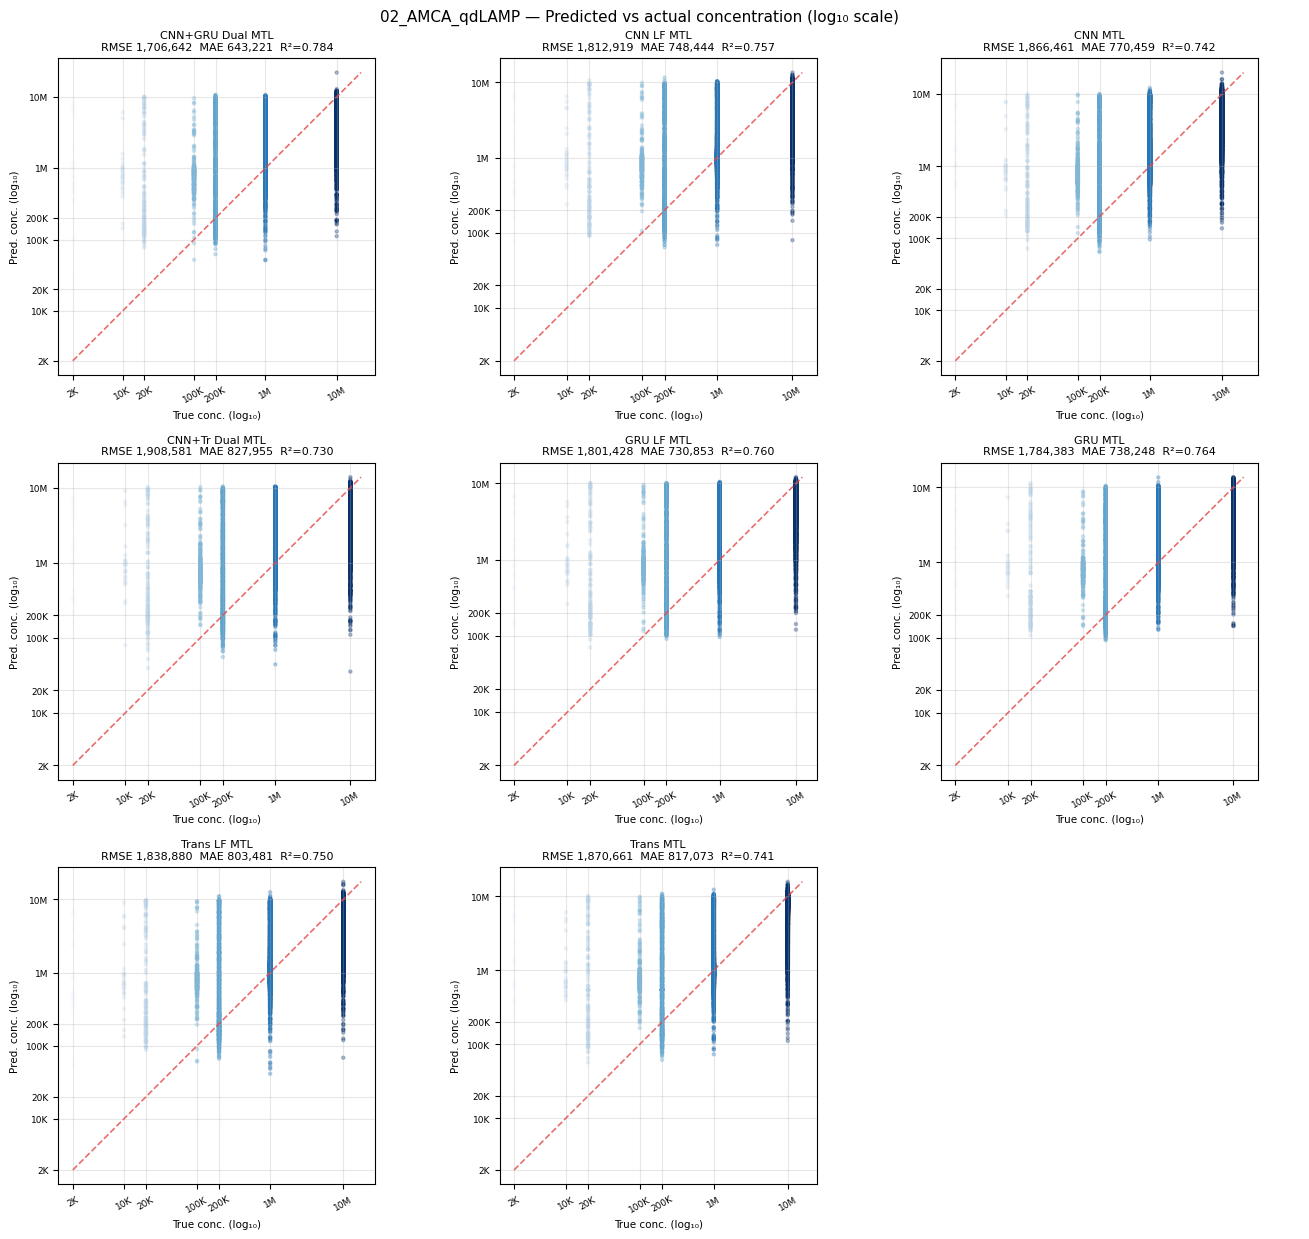

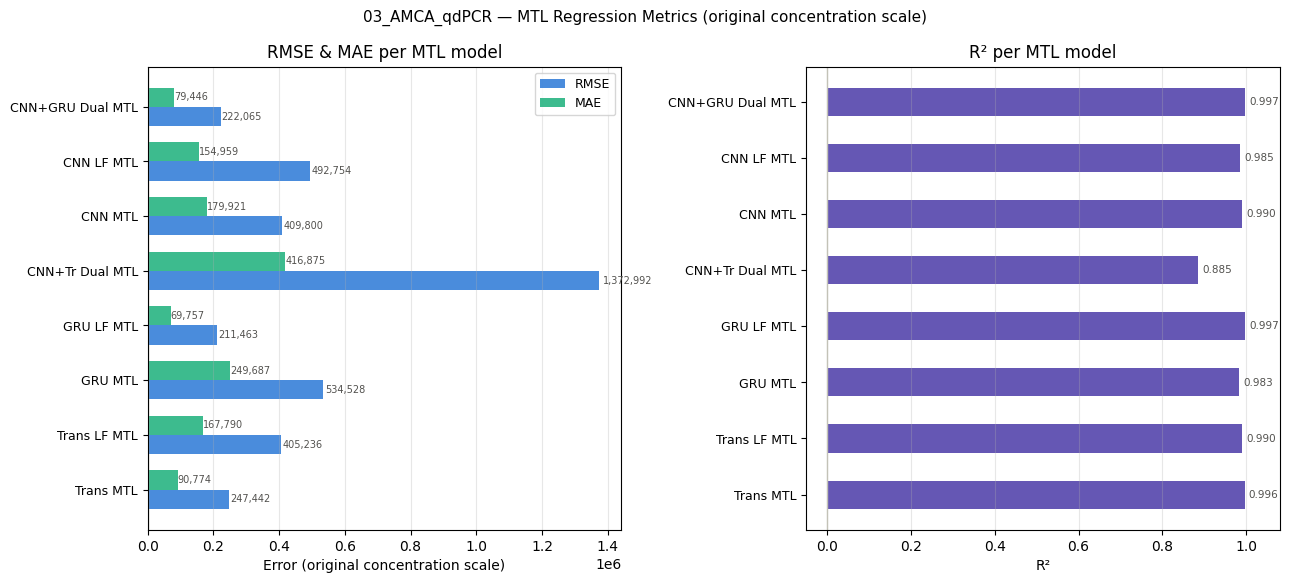

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"222,065.4","79,446.0",0.9970,58598
CNN LF MTL,"492,753.6","154,959.2",0.9852,58598
CNN MTL,"409,800.3","179,921.2",0.9898,58598
CNN+Tr Dual MTL,"1,372,991.8","416,874.9",0.8852,58598
GRU LF MTL,"211,463.1","69,756.5",0.9973,58598
GRU MTL,"534,527.5","249,687.4",0.9826,58598
Trans LF MTL,"405,236.2","167,790.0",0.9900,58598
Trans MTL,"247,442.2","90,774.0",0.9963,58598


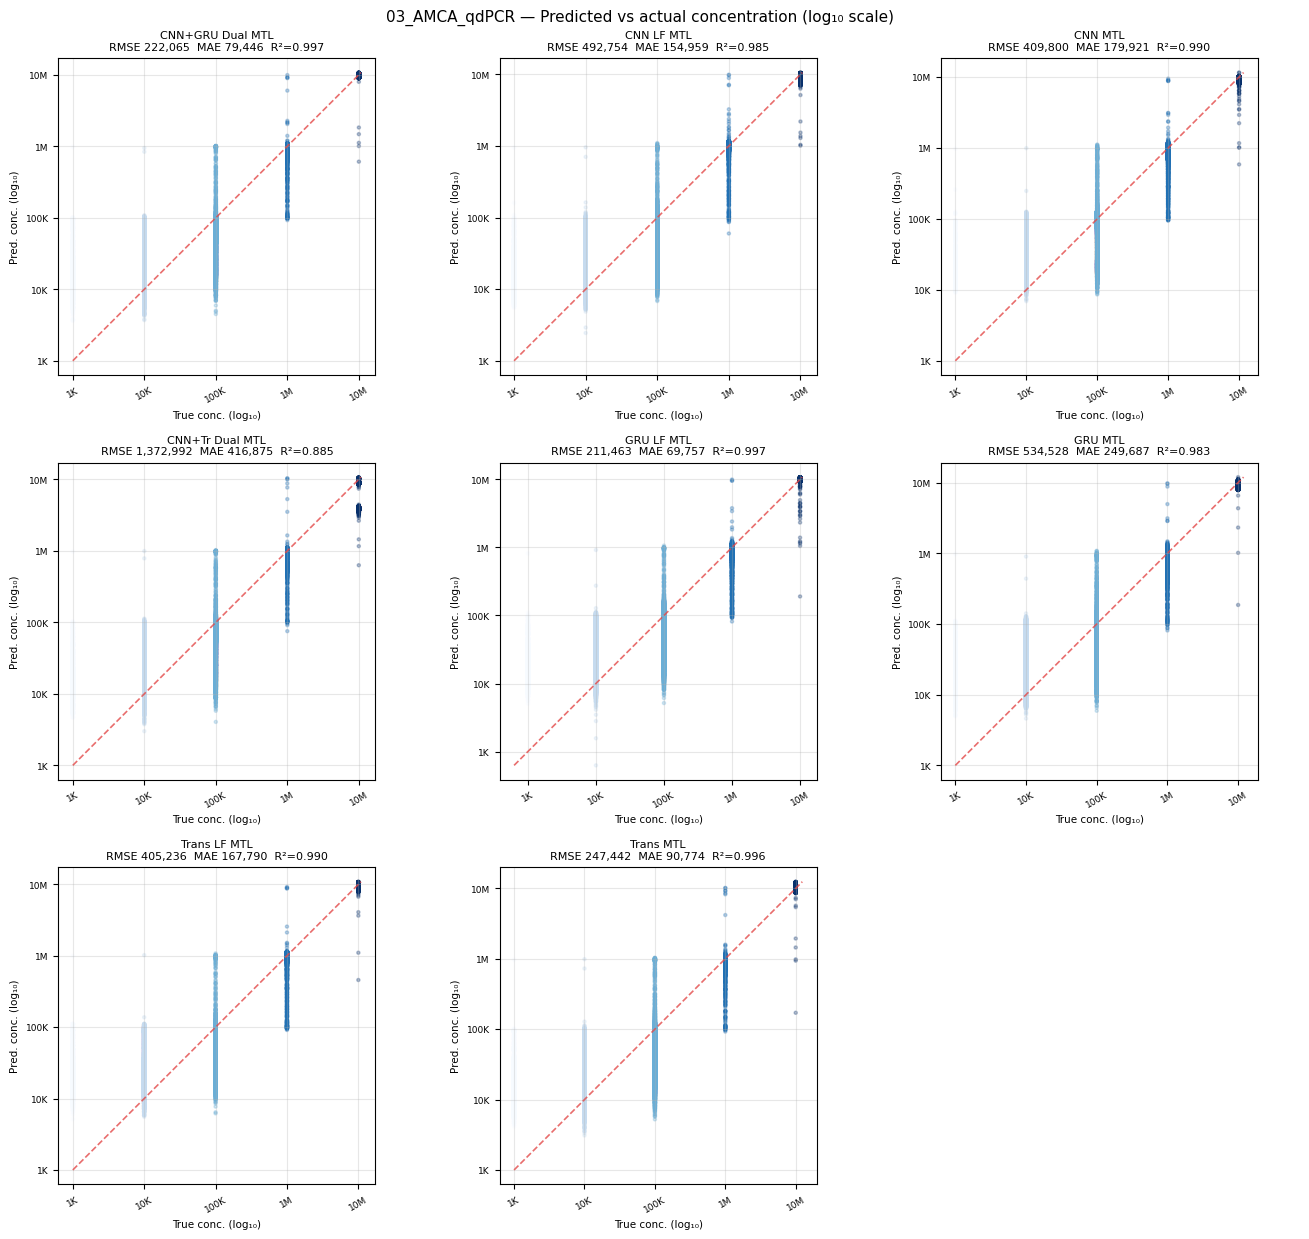

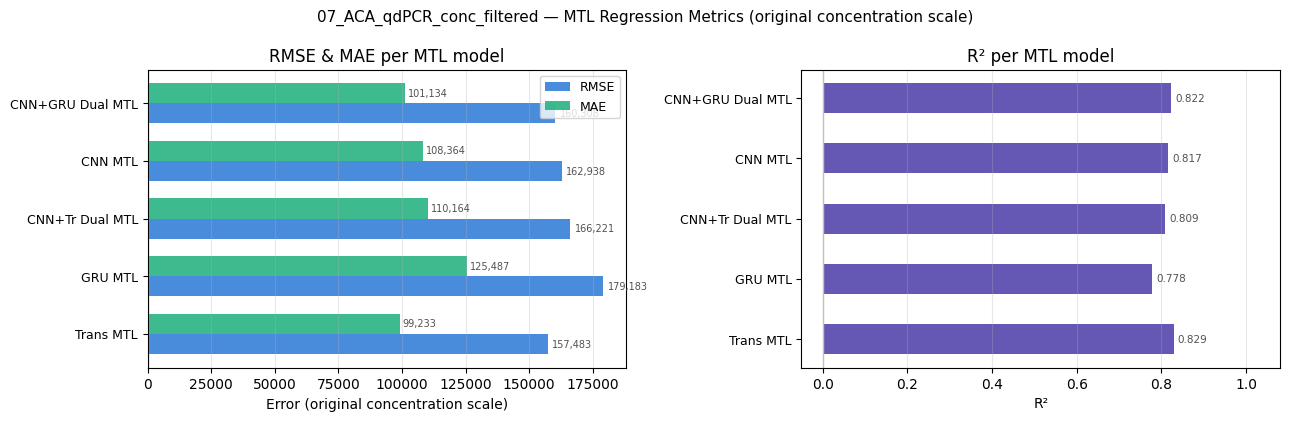

,RMSE,MAE,R²,N valid
Model,,,,
CNN+GRU Dual MTL,"160,307.6","101,133.6",0.8224,15146
CNN MTL,"162,938.2","108,364.0",0.8165,15146
CNN+Tr Dual MTL,"166,221.3","110,163.8",0.8091,15146
GRU MTL,"179,183.3","125,487.0",0.7781,15146
Trans MTL,"157,482.6","99,233.4",0.8286,15146


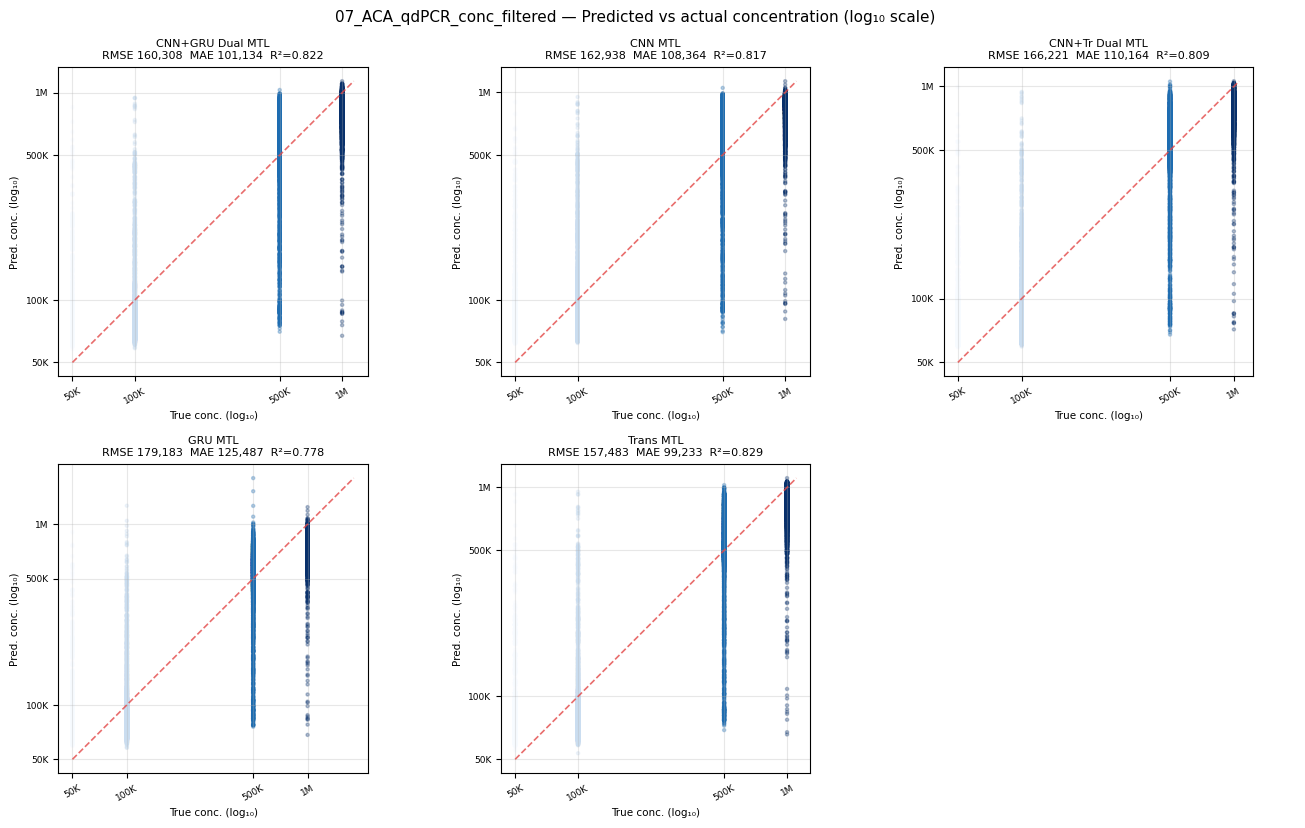

[!] No regression data — no MTL reg keys found in results.
[!] No regression data.


In [20]:
for _folder in _folders:
    _raw = load_results(_folder)
    if _raw is None:
        continue
    _res, _, _ = _get_res_entry(_raw, OUTLIER_FILTER)
    if _res is None:
        print(f'[!] {_folder}: no entry for filter={OUTLIER_FILTER!r}. Skipping.')
        continue

    reg_data = collect_reg_results(_res)

    # plot_stmtl_comparison(_res, _folder)
    plot_reg_metrics(reg_data, _folder)
    plot_reg_scatter(reg_data, _folder, log10_scale=True)
    # plot_reg_residuals(reg_data, _folder)

In [55]:
def plot_model_across_folders(folders, model_key, outlier_filter=OUTLIER_FILTER):
    mtl_key        = model_key + '_mtl'
    sc_key         = model_key + '_supcon'
    sc_mtl_key     = model_key + '_supcon_mtl'

    def _fold_accs(res, key):
        pk = f'y_preds_AC_{key}_'
        if pk not in res or 'y_trues_' not in res:
            return None
        return np.array([np.mean(np.array(yt) == np.array(yp))
                         for yt, yp in zip(res['y_trues_'], res[pk])]) * 100

    methods = [
        ('ST',          model_key,    'steelblue'),
        ('MTL',         mtl_key,      'darkorange'),
        ('ST SupCon',   sc_key,       'mediumseagreen'),
        ('MTL SupCon',  sc_mtl_key,   'mediumpurple'),
    ]

    data   = {label: ([], []) for label, *_ in methods}  # label -> (means, stds)
    labels = []

    for folder in folders:
        all_res = load_results(folder)
        if all_res is None:
            continue
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is None:
            continue

        accs = {label: _fold_accs(res, key) for label, key, _ in methods}
        if all(v is None for v in accs.values()):
            continue

        labels.append(folder)
        for label, key, _ in methods:
            a = accs[label]
            data[label][0].append(a.mean() if a is not None else np.nan)
            data[label][1].append(a.std()  if a is not None else 0)

    if not labels:
        print('No data found.')
        return

    n  = len(labels)
    w  = 0.20
    x  = np.arange(n)
    offsets = [-1.5 * w, -0.5 * w, 0.5 * w, 1.5 * w]

    fig, ax = plt.subplots(figsize=(max(6, n * 2.5), 5))

    for (label, _, color), offset in zip(methods, offsets):
        means, stds = data[label]
        ax.bar(x + offset, means, w, yerr=stds, label=label,
               capsize=3, alpha=0.85, color=color)
        for xi, v in enumerate(means):
            if not np.isnan(v):
                ax.text(xi + offset, v + 0.3, f'{v:.1f}%',
                        ha='center', fontsize=8, color=color, fontweight='bold')

    all_vals = [v for lbl, *_ in methods for v in data[lbl][0] if not np.isnan(v)]
    if all_vals:
        ax.set_ylim(max(0, min(all_vals) - 5), 100)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Mean fold accuracy (%)', fontsize=10)
    ax.set_title(
        f'ST vs MTL vs SupCon Performance Across Datasets\nModel: {model_key}',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    plt.tight_layout()
    plt.show()


# -- Shared helpers -----------------------------------------------------------

def _extract_reg_folds(res, model_key, sentinel=-1.0):
    """Return list of (trues, preds) per fold, sentinel-masked."""
    pk = f'y_reg_preds_{model_key}_'
    tk = f'y_reg_trues_{model_key}_'
    if pk not in res or tk not in res:
        return None
    out = []
    for preds, trues in zip(res[pk], res[tk]):
        p, t = np.array(preds), np.array(trues)
        mask = t != sentinel
        if mask.sum() > 0:
            out.append((t[mask], p[mask]))
    return out or None


def _reg_metrics_fold(trues, preds):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from scipy.stats import pearsonr
    mae  = mean_absolute_error(trues, preds)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    r2   = r2_score(trues, preds)
    r, _ = pearsonr(trues, preds)
    return dict(MAE=mae, RMSE=rmse, R2=r2, r=r)


# -- Across-folders versions --------------------------------------------------

def plot_reg_metrics_across_folders(folders, model_key,
                                     outlier_filter=OUTLIER_FILTER, sentinel=-1.0):
    """Bar chart of regression metrics (mean +/- std across folds) for each dataset."""
    data = {}
    for folder in folders:
        all_res = load_results(folder)
        if all_res is None:
            continue
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is None:
            continue
        fold_pairs = _extract_reg_folds(res, model_key, sentinel)
        if fold_pairs is None:
            continue
        data[folder] = [_reg_metrics_fold(t, p) for t, p in fold_pairs]

    if not data:
        print('No regression data found.')
        return

    labels     = list(data.keys())
    metric_keys = ['MAE', 'RMSE', 'R2', 'r']
    x = np.arange(len(labels))

    fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
    for ax, m in zip(axes, metric_keys):
        means = [np.mean([f[m] for f in data[fld]]) for fld in labels]
        stds  = [np.std( [f[m] for f in data[fld]]) for fld in labels]
        ax.bar(x, means, yerr=stds, capsize=4, alpha=0.85, color='steelblue')
        for xi, (mn, sd) in enumerate(zip(means, stds)):
            ax.text(xi, mn + sd + (max(means) - min(means)) * 0.03,
                    f'{mn:.3f}', ha='center', fontsize=7.5)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
        ax.set_title(m, fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linewidth=0.7)
        if m in ('R2', 'r'):
            ax.set_ylim(top=1.05)

    fig.suptitle(f'Regression metrics  [{model_key}]  across datasets',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_reg_scatter_across_folders(folders, model_key, log10_scale=True,
                                     outlier_filter=OUTLIER_FILTER, sentinel=-1.0):

    data = {}
    for folder in folders:
        all_res = load_results(folder)
        if all_res is None:
            continue
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is None:
            continue
        fold_pairs = _extract_reg_folds(res, model_key, sentinel)
        if fold_pairs is None:
            continue
        data[folder] = fold_pairs

    if not data:
        print('No regression data found.')
        return

    labels = list(data.keys())
    fig, axes = plt.subplots(1, len(labels), figsize=(4.5 * len(labels), 4.2), squeeze=False)

    for ax, folder in zip(axes[0], labels):
        trues_raw = np.concatenate([t for t, _ in data[folder]])
        preds_raw = np.concatenate([p for _, p in data[folder]])

        m = _reg_metrics_fold(trues_raw, preds_raw)

        if log10_scale:
            t_plot = np.log10(np.maximum(trues_raw, 0.1))
            p_plot = np.log10(np.maximum(preds_raw, 0.1))
        else:
            t_plot, p_plot = trues_raw, preds_raw

        xlabel, ylabel = 'True concentration', 'Pred. concentration'

        ax.scatter(t_plot, p_plot, s=5, alpha=0.3,
                   c=t_plot, cmap='Blues',
                   vmin=t_plot.min(), vmax=t_plot.max(),
                   rasterized=True)

        lo = min(t_plot.min(), p_plot.min())
        hi = max(t_plot.max(), p_plot.max())
        ax.plot([lo, hi], [lo, hi], color='#e34948', linewidth=1.2,
                linestyle='--', alpha=0.8)

        unique_c = sorted(np.unique(np.round(trues_raw, 0)))
        if log10_scale:
            ticks = np.log10(np.maximum(unique_c, 0.1))
        else:
            ticks = unique_c
        ax.set_xticks(ticks)
        ax.set_xticklabels([_conc_label(c) for c in unique_c], rotation=30, fontsize=6.5)
        ax.set_yticks(ticks)
        ax.set_yticklabels([_conc_label(c) for c in unique_c], fontsize=6.5)

        ax.set_title(
            f"{folder}\nRMSE {m['RMSE']:,.0f}  MAE {m['MAE']:,.0f}  R²={m['R2']:.3f}",
            fontsize=8)
        ax.set_xlabel(xlabel, fontsize=7.5)
        ax.set_ylabel(ylabel, fontsize=7.5)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(alpha=0.3, linewidth=0.8)

    scale_label = 'log₁₀ scale' if log10_scale else 'original scale'
    fig.suptitle(f'Predicted vs Actual Concentration Across Datasets (Model: {model_key})',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

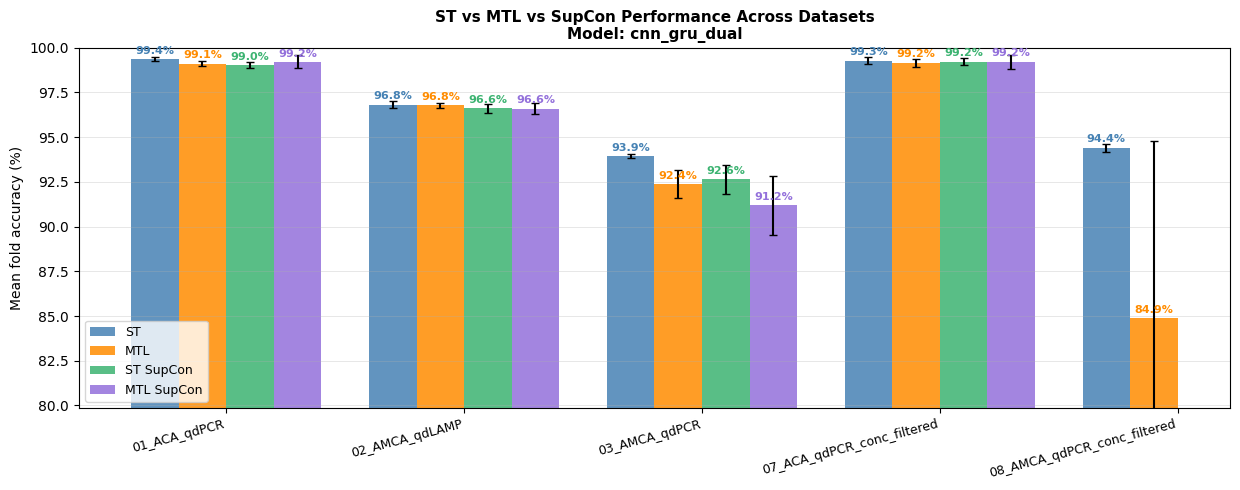

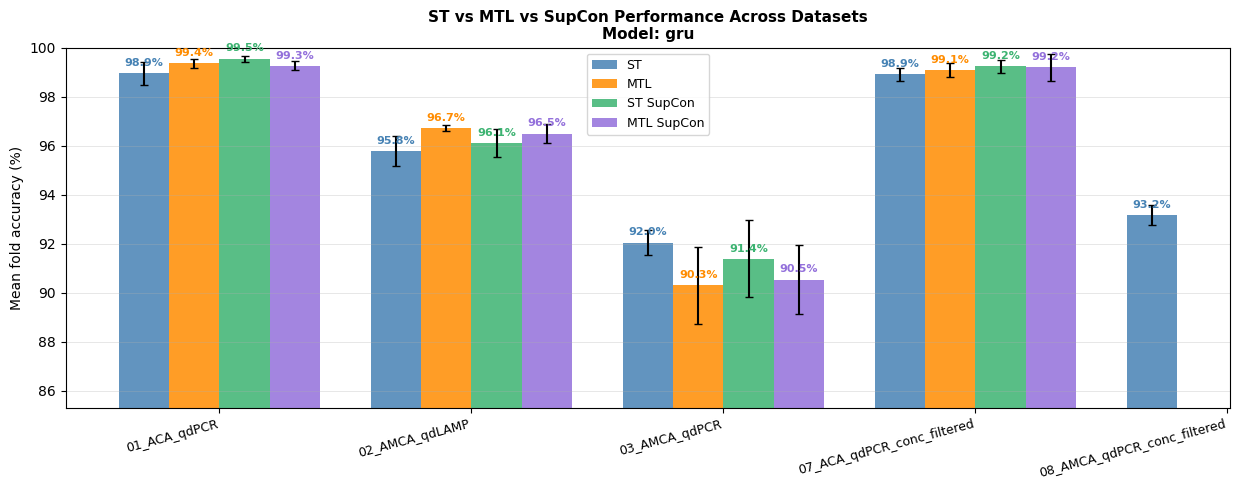

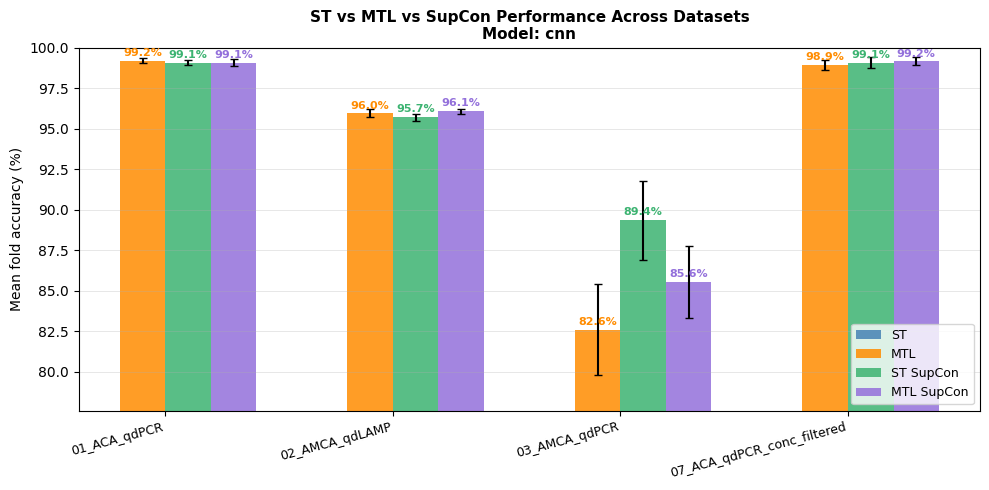

In [60]:
_folders = ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered']
plot_model_across_folders(_folders,model_key='cnn_gru_dual',outlier_filter=None)
plot_model_across_folders(_folders,model_key='gru',outlier_filter=None)
plot_model_across_folders(_folders,model_key='cnn',outlier_filter=None)
# plot_reg_metrics_across_folders(_folders, model_key='cnn_gru_dual_mtl')
# plot_reg_scatter_across_folders(_folders, model_key='cnn_gru_dual_mtl', log10_scale=True)


In [23]:
def plot_conc_distribution_per_folder(folders):
    """One bar chart per dataset: x = concentration level, y = sample count."""
    n = len(folders)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)

    for ax, folder in zip(axes[0], folders):
        d = load_folder_data(folder)
        valid = ~np.isnan(d['concentration'])
        con_v = d['concentration'][valid]

        sorted_conc = sorted(np.unique(con_v))
        counts      = [int(np.sum(con_v == c)) for c in sorted_conc]
        col_labels  = [_conc_label(c) for c in sorted_conc]

        bars = ax.bar(range(len(sorted_conc)), counts, color='steelblue', alpha=0.85, edgecolor='white')
        for xi, v in enumerate(counts):
            ax.text(xi, v + max(counts) * 0.02, str(v),
                    ha='center', fontsize=8.5, fontweight='bold', color='steelblue')

        ax.set_xticks(range(len(sorted_conc)))
        ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel('Sample count', fontsize=9)
        ax.set_title(f'{folder}\n(n={sum(counts)})', fontsize=9, fontweight='bold')
        ax.set_ylim(0, max(counts) * 1.15)
        ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    fig.suptitle('Sample count by concentration — per dataset', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


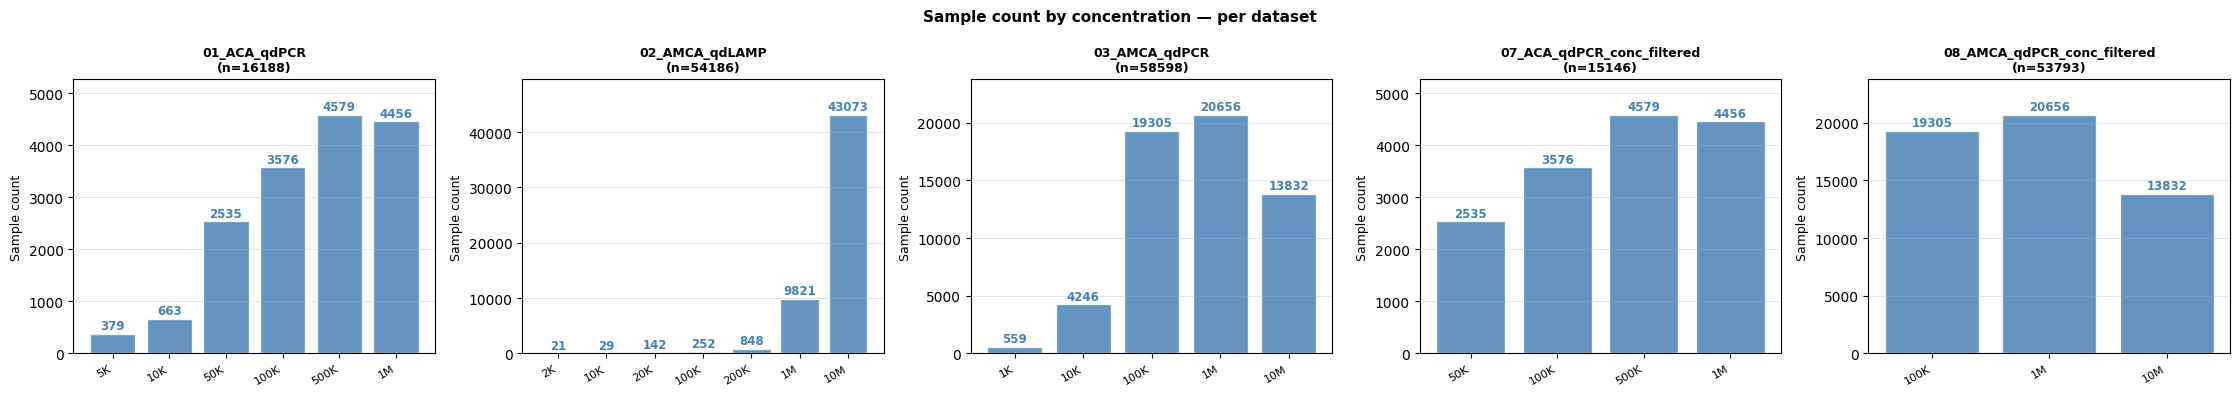

In [24]:
plot_conc_distribution_per_folder(['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered'])


---
## Section 9 · TTP × Confusion Analysis (single-task, all folders)

Four panels per folder — links classification errors to TTP overlap:

- **A** — ST confusion matrix: rows = (true target, concentration), cols = predicted target
- **B** — TTP boxplot per target × concentration (10% threshold)
- **C** — Mean TTP per group sorted → adjacent rows = TTP-overlap risk
- **D** — Scatter: TTP distance to closest same-pred-class group vs confusion rate; top-left cluster = TTP-driven errors

In [25]:
ST_ANALYSIS_MODEL = 'cnn_gru_dual'   # change to any single-task key in config.MODEL_KEY_MAP


# ── helpers ───────────────────────────────────────────────────────────────────

def _compute_ttp_10pct(curves):
    """First cycle where signal > baseline + 10% × (peak − baseline)."""
    baseline = curves[:, 0:1]
    peak     = curves.max(axis=1, keepdims=True)
    thresh   = baseline + 0.1 * (peak - baseline)
    exceeded = curves > thresh
    ttp = np.argmax(exceeded, axis=1)
    ttp[~exceeded.any(axis=1)] = curves.shape[1] - 1
    return ttp


def _build_group_ttp(ori_v, lbl_v, con_v, unique_tgt, unique_conc):
    """{(tgt, conc): (mean, std, n, ttp_array)} for each non-empty group."""
    ttp = _compute_ttp_10pct(ori_v)
    out = {}
    for tgt in unique_tgt:
        for c in unique_conc:
            m = (lbl_v == tgt) & (con_v == c)
            if not m.any():
                continue
            t = ttp[m]
            out[(tgt, c)] = (float(t.mean()), float(t.std()), int(m.sum()), t)
    return out


# ── main plotting function ────────────────────────────────────────────────────

def plot_ttp_confusion_analysis(folder, st_model_key=ST_ANALYSIS_MODEL,
                                 outlier_filter=OUTLIER_FILTER, n_splits=N_SPLITS):

    # data
    d = load_folder_data(folder)
    ori, labels, conc = d['ori_curves'], d['labels'], d['concentration']
    _assign_target_colors(labels)

    valid = ~np.isnan(conc)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], conc[valid]
    unique_tgt  = sorted(np.unique(lbl_v))
    unique_conc = sorted(np.unique(con_v))

    group_ttp = _build_group_ttp(ori_v, lbl_v, con_v, unique_tgt, unique_conc)

    # predictions
    pred_df = None
    all_res = load_results(folder)
    if all_res is not None:
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is not None:
            fold_concs, fold_lbl, le = _reconstruct_fold_conc(labels, conc, n_splits, outlier_filter)
            pred_df = build_prediction_df(res, st_model_key, fold_concs, fold_lbl, le)

    # adaptive figure height: A and C rows scale with number of groups
    n_g    = len(group_ttp)
    row_h  = max(6.0, n_g * 0.32)
    fig    = plt.figure(figsize=(20, row_h + 6.5))
    gs     = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35,
                               height_ratios=[row_h, 5.5])
    ax_cm   = fig.add_subplot(gs[0, 0])   # A: confusion matrix
    ax_dot  = fig.add_subplot(gs[0, 1])   # C: sorted TTP dotplot
    ax_ttp  = fig.add_subplot(gs[1, 0])   # B: TTP boxplot
    ax_scat = fig.add_subplot(gs[1, 1])   # D: TTP dist vs confusion rate

    # ── Panel A: Confusion matrix ─────────────────────────────────────────────
    row_keys   = [(tgt, c) for tgt in unique_tgt for c in unique_conc if (tgt, c) in group_ttp]
    row_lbls   = [f'{tgt} / {_conc_label(c)}' for tgt, c in row_keys]
    col_lbls   = unique_tgt
    mat        = np.full((len(row_keys), len(col_lbls)), np.nan)

    if pred_df is not None and not pred_df.empty:
        vp = pred_df[~np.isnan(pred_df['concentration'])].copy()
        for ri, (tgt, c) in enumerate(row_keys):
            sub = vp[(vp['true_label'] == tgt) & (vp['concentration'] == c)]
            if len(sub) == 0:
                continue
            for ci, ptgt in enumerate(col_lbls):
                mat[ri, ci] = (sub['pred_label'] == ptgt).sum() / len(sub)

    im = ax_cm.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax_cm, fraction=0.03, pad=0.04, label='Fraction')
    ax_cm.set_xticks(range(len(col_lbls)))
    ax_cm.set_xticklabels(col_lbls, rotation=30, ha='right', fontsize=8)
    ax_cm.set_yticks(range(len(row_keys)))
    fs_y = 6.0 if len(row_keys) > 28 else 7.5
    ax_cm.set_yticklabels(row_lbls, fontsize=fs_y)
    ax_cm.set_xlabel('Predicted target', fontsize=9)
    ax_cm.set_ylabel('True  (target / concentration)', fontsize=9)
    # annotate cells (skip if grid too large)
    if len(row_keys) * len(col_lbls) <= 120:
        for ri, (tgt, _) in enumerate(row_keys):
            for ci in range(len(col_lbls)):
                v = mat[ri, ci]
                if not np.isnan(v):
                    ax_cm.text(ci, ri, f'{v:.2f}', ha='center', va='center',
                               fontsize=5.5, color='white' if v > 0.6 else '#444')
    # black border on diagonal cells
    for ri, (tgt, _) in enumerate(row_keys):
        if tgt in col_lbls:
            di = col_lbls.index(tgt)
            ax_cm.add_patch(plt.Rectangle((di - 0.5, ri - 0.5), 1, 1,
                                           fill=False, edgecolor='black', lw=1.0))
    ax_cm.set_title(f'A. ST confusion matrix  [{st_model_key}]\n'
                    f'rows = true (target, conc)  |  cols = predicted target',
                    fontsize=9, fontweight='bold')

    # ── Panel C: Mean TTP sorted dotplot ─────────────────────────────────────
    sorted_grps = sorted(group_ttp, key=lambda k: group_ttp[k][0])
    means = np.array([group_ttp[k][0] for k in sorted_grps])
    stds  = np.array([group_ttp[k][1] for k in sorted_grps])
    y_pos = np.arange(len(sorted_grps))
    dot_c = [TARGET_COLORS.get(k[0], 'gray') for k in sorted_grps]
    dot_l = [f'{k[0]} / {_conc_label(k[1])}' for k in sorted_grps]

    ax_dot.errorbar(means, y_pos, xerr=stds, fmt='none',
                    ecolor='#ccc', elinewidth=1.0, capsize=2, zorder=1)
    ax_dot.scatter(means, y_pos, c=dot_c, s=55, zorder=3,
                   edgecolors='white', linewidths=0.5)
    ax_dot.set_yticks(y_pos)
    ax_dot.set_yticklabels(dot_l, fontsize=fs_y)
    ax_dot.invert_yaxis()
    ax_dot.set_xlabel('Mean TTP (cycle index)', fontsize=9)
    ax_dot.grid(axis='x', alpha=0.3, linewidth=0.7)
    ax_dot.legend(
        handles=[plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=TARGET_COLORS.get(t, 'gray'),
                             markersize=8, label=t) for t in unique_tgt],
        title='Target', fontsize=7, title_fontsize=7, loc='lower right')
    ax_dot.set_title('C. Mean TTP per group, sorted (mean ± std)\n'
                     'Adjacent rows = similar TTP = overlap risk',
                     fontsize=9, fontweight='bold')

    # ── Panel B: TTP boxplot — x=target, hue=concentration ───────────────────
    ttp_records = [
        {'target': tgt, 'conc_lbl': _conc_label(c), 'ttp': float(v)}
        for (tgt, c), (_, _, _, arr) in group_ttp.items()
        for v in arr
    ]
    ttp_df_box  = pd.DataFrame(ttp_records)
    n_conc      = len(unique_conc)
    # single-hue sequential: Oranges light (low conc) → dark (high conc)
    oran_ramp   = plt.get_cmap('Oranges')(np.linspace(0.30, 0.88, n_conc))
    conc_pal    = {_conc_label(c): tuple(oran_ramp[i]) for i, c in enumerate(unique_conc)}
    conc_order  = [_conc_label(c) for c in unique_conc]

    if not ttp_df_box.empty:
        sns.boxplot(data=ttp_df_box, x='target', y='ttp', hue='conc_lbl',
                    hue_order=conc_order, palette=conc_pal, ax=ax_ttp,
                    linewidth=0.8, fliersize=1.5, width=0.7)
        ax_ttp.set_xlabel('Target', fontsize=9)
        ax_ttp.set_ylabel('TTP (cycle index, 10% threshold)', fontsize=9)
        ax_ttp.grid(axis='y', alpha=0.3, linewidth=0.7)
        leg = ax_ttp.get_legend()
        if leg:
            leg.set_title('Concentration', prop={'size': 8})
            for t in leg.texts:
                t.set_fontsize(7)
    ax_ttp.set_title('B. TTP distribution per target × concentration\n'
                     '(Oranges light→dark = low→high conc)',
                     fontsize=9, fontweight='bold')

    # ── Panel D: TTP distance vs confusion rate ───────────────────────────────
    # Each point = one off-diagonal confusion pair (true_group → wrong_pred_target)
    # x = min |mean TTP true_group − mean TTP of pred_target at any conc|
    # y = confusion rate; top-left cluster confirms TTP-driven misclassification
    pts = []
    if pred_df is not None and not pred_df.empty:
        vp = pred_df[~np.isnan(pred_df['concentration'])].copy()
        for (true_tgt, true_c), (mean_ttp_true, _, _, _) in group_ttp.items():
            sub = vp[(vp['true_label'] == true_tgt) & (vp['concentration'] == true_c)]
            if len(sub) < 3:
                continue
            for pred_tgt in unique_tgt:
                if pred_tgt == true_tgt:
                    continue
                conf = (sub['pred_label'] == pred_tgt).sum() / len(sub)
                if conf < 1e-5:
                    continue
                pred_means = [group_ttp[(pred_tgt, c)][0]
                              for c in unique_conc if (pred_tgt, c) in group_ttp]
                if not pred_means:
                    continue
                pts.append(dict(
                    x=min(abs(mean_ttp_true - pm) for pm in pred_means),
                    y=conf * 100,
                    lbl=f'{true_tgt}/{_conc_label(true_c)}→{pred_tgt}',
                    color=TARGET_COLORS.get(true_tgt, 'gray'),
                ))

    if pts:
        ax_scat.scatter([p['x'] for p in pts], [p['y'] for p in pts],
                        c=[p['color'] for p in pts], s=45, alpha=0.75,
                        edgecolors='white', linewidths=0.5, zorder=3)
        ax_scat.set_xlabel('Min. TTP distance to closest same-pred-class group (cycles)', fontsize=8)
        ax_scat.set_ylabel('Confusion rate (%)', fontsize=9)
        ax_scat.grid(alpha=0.3, linewidth=0.7)
        for p in sorted(pts, key=lambda p: -p['y'] / (p['x'] + 0.5))[:6]:
            ax_scat.annotate(p['lbl'], (p['x'], p['y']), fontsize=6,
                             xytext=(4, 3), textcoords='offset points',
                             color=p['color'], fontweight='bold')
        ax_scat.legend(
            handles=[plt.Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=TARGET_COLORS.get(t, 'gray'),
                                 markersize=7, label=t) for t in unique_tgt],
            title='True target', fontsize=7, title_fontsize=7, loc='upper right')
    else:
        ax_scat.text(0.5, 0.5, 'No confusions found\n(or no prediction data)',
                     ha='center', va='center', transform=ax_scat.transAxes,
                     fontsize=10, color='gray')
    ax_scat.set_title('D. Does TTP overlap drive misclassification?\n'
                      'top-left = high confusion + small TTP distance',
                      fontsize=9, fontweight='bold')

    fig.suptitle(f'{folder} — TTP × Confusion Analysis  [{st_model_key}  ST]',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()



---
## Section 10 · Curve-Shape Similarity × Confusion Analysis (v2)

Same 4-panel structure as Section 9 but replaces TTP with **normalized curve distance**:

- Metric: baseline-correct → scale to [0,1] → L2 distance on mean curves per group
  (amplitude-invariant — isolates shape from concentration level; complementary to TTP analysis)
- **B** — pairwise similarity heatmap across all (target, conc) groups
- **C** — 2D MDS embedding in curve-shape space
- **D** — curve distance vs confusion rate (top-left = shape-driven confusion)

*Note: `DTW` would be better when TTP shift is the main difference between groups; since that's already captured in Section 9, normalizing it out here makes the two analyses complementary.*

In [26]:
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances


def _norm01_curve(curve):
    """Baseline-correct (subtract first point) then scale to [0,1]."""
    c = curve - curve[0]
    r = c.max() - c.min()
    return c / r if r > 1e-10 else np.zeros_like(c)


def _group_distance_matrix(group_mean, sorted_grps):
    """Pairwise normalized-Euclidean distance between group mean curves.
    
    Each mean curve is independently normalized to [0,1] before computing L2,
    making the distance amplitude-invariant (shape-only comparison).
    Returns (D, sim) where sim = 1 - D / D.max().
    """
    norm_mean = np.array([_norm01_curve(group_mean[k]) for k in sorted_grps])
    D = pairwise_distances(norm_mean, metric='euclidean')
    sim = 1.0 - D / (D.max() + 1e-8)
    return D, sim


def plot_curve_similarity_analysis(folder, st_model_key=ST_ANALYSIS_MODEL,
                                    outlier_filter=OUTLIER_FILTER, n_splits=N_SPLITS, sim_cm_min=0.95):

    # ── Data ──────────────────────────────────────────────────────────────────
    d = load_folder_data(folder)
    ori, labels, conc = d['ori_curves'], d['labels'], d['concentration']
    _assign_target_colors(labels)

    valid = ~np.isnan(conc)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], conc[valid]
    unique_tgt  = sorted(np.unique(lbl_v))
    unique_conc = sorted(np.unique(con_v))

    group_ttp  = _build_group_ttp(ori_v, lbl_v, con_v, unique_tgt, unique_conc)
    group_mean = {k: ori_v[(lbl_v == k[0]) & (con_v == k[1])].mean(axis=0)
                  for k in group_ttp}

    # TTP order — used for D matrix and MDS (Panel C)
    sorted_grps = sorted(group_ttp, key=lambda k: group_ttp[k][0])
    n_g = len(sorted_grps)

    D, sim = _group_distance_matrix(group_mean, sorted_grps)
    grp_to_idx = {k: i for i, k in enumerate(sorted_grps)}

    # Label order (target outer, conc inner) — same as confusion matrix
    row_keys = [(tgt, c) for tgt in unique_tgt for c in unique_conc if (tgt, c) in group_ttp]
    cm_idxs  = [grp_to_idx[k] for k in row_keys]
    sim_cm   = sim[np.ix_(cm_idxs, cm_idxs)]

    # ── Predictions ───────────────────────────────────────────────────────────
    pred_df = None
    all_res = load_results(folder)
    if all_res is not None:
        res, _, _ = _get_res_entry(all_res, outlier_filter)
        if res is not None:
            fold_concs, fold_lbl, le = _reconstruct_fold_conc(labels, conc, n_splits, outlier_filter)
            pred_df = build_prediction_df(res, st_model_key, fold_concs, fold_lbl, le)

    # ── Layout ────────────────────────────────────────────────────────────────
    row_h  = max(6.0, n_g * 0.32)
    heat_h = max(5.5, n_g * 0.25)
    fs_y   = 6.0 if n_g > 28 else 7.5
    tick_fs = 5.0 if n_g > 20 else 7.0

    fig = plt.figure(figsize=(20, row_h + heat_h + 1.5))
    gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35,
                            height_ratios=[row_h, heat_h])
    ax_cm   = fig.add_subplot(gs[0, 0])
    ax_mds  = fig.add_subplot(gs[0, 1])
    ax_heat = fig.add_subplot(gs[1, 0])
    ax_scat = fig.add_subplot(gs[1, 1])

    # ── Panel A: Confusion matrix ─────────────────────────────────────────────
    row_lbls = [f'{tgt} / {_conc_label(c)}' for tgt, c in row_keys]
    col_lbls = unique_tgt
    mat = np.full((len(row_keys), len(col_lbls)), np.nan)

    if pred_df is not None and not pred_df.empty:
        vp = pred_df[~np.isnan(pred_df['concentration'])].copy()
        for ri, (tgt, c) in enumerate(row_keys):
            sub = vp[(vp['true_label'] == tgt) & (vp['concentration'] == c)]
            if len(sub) == 0:
                continue
            for ci, ptgt in enumerate(col_lbls):
                mat[ri, ci] = (sub['pred_label'] == ptgt).sum() / len(sub)

    im = ax_cm.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax_cm, fraction=0.03, pad=0.04, label='Fraction')
    ax_cm.set_xticks(range(len(col_lbls)))
    ax_cm.set_xticklabels(col_lbls, rotation=30, ha='right', fontsize=8)
    ax_cm.set_yticks(range(len(row_keys)))
    ax_cm.set_yticklabels(row_lbls, fontsize=fs_y)
    ax_cm.set_xlabel('Predicted target', fontsize=9)
    ax_cm.set_ylabel('True  (target / concentration)', fontsize=9)
    if len(row_keys) * len(col_lbls) <= 120:
        for ri, (tgt, _) in enumerate(row_keys):
            for ci in range(len(col_lbls)):
                v = mat[ri, ci]
                if not np.isnan(v):
                    ax_cm.text(ci, ri, f'{v:.2f}', ha='center', va='center',
                               fontsize=5.5, color='white' if v > 0.6 else '#444')
    for ri, (tgt, _) in enumerate(row_keys):
        if tgt in col_lbls:
            di = col_lbls.index(tgt)
            ax_cm.add_patch(plt.Rectangle((di - 0.5, ri - 0.5), 1, 1,
                                           fill=False, edgecolor='black', lw=1.0))
    ax_cm.set_title(f'A. ST confusion matrix  [{st_model_key}]\n'
                    f'rows = true (target, conc)  |  cols = predicted target',
                    fontsize=9, fontweight='bold')

    # ── Panel B: Pairwise curve similarity heatmap ────────────────────────────
    # axes sorted by label order (same as Panel A) for direct side-by-side comparison
    tick_lbls_h = [f'{k[0]}/{_conc_label(k[1])}' for k in row_keys]

    same_tgt = np.array([[row_keys[i][0] == row_keys[j][0]
                       for j in range(len(row_keys))]
                      for i in range(len(row_keys))])
    im_h = ax_heat.imshow(np.where((sim_cm < sim_cm_min) | same_tgt, 0, sim_cm),
                        aspect='auto', cmap='Blues', vmin=0, vmax=1)

    plt.colorbar(im_h, ax=ax_heat, fraction=0.03, pad=0.04,
                 label='Normalized curve similarity  (1 = identical shape, 0 = maximally different)')
    ax_heat.set_xticks(range(n_g))
    ax_heat.set_xticklabels(tick_lbls_h, rotation=90, fontsize=tick_fs)
    ax_heat.set_yticks(range(n_g))
    ax_heat.set_yticklabels(tick_lbls_h, fontsize=tick_fs)

    # white dividers between target groups (contiguous blocks in label order)
    prev = row_keys[0][0]
    for i, k in enumerate(row_keys):
        if k[0] != prev:
            ax_heat.axhline(i - 0.5, color='white', lw=1.0, alpha=0.7)
            ax_heat.axvline(i - 0.5, color='white', lw=1.0, alpha=0.7)
            prev = k[0]

    ax_heat.set_title('B. Pairwise normalized curve similarity  (sorted by label — same as Panel A)\n'
                      'dark blue = similar shape; white = maximally different',
                      fontsize=9, fontweight='bold')

    # ── Panel C: 2D MDS embedding in curve-shape space ───────────────────────
    coords = MDS(n_components=2, dissimilarity='precomputed',
                 random_state=42, n_init=4).fit_transform(D)

    for i, k in enumerate(sorted_grps):
        c_col = TARGET_COLORS.get(k[0], 'gray')
        n_samp = group_ttp[k][2]
        ax_mds.scatter(coords[i, 0], coords[i, 1], color=c_col,
                       s=40 + n_samp / max(gt[2] for gt in group_ttp.values()) * 80,
                       edgecolors='white', linewidths=0.6, zorder=3)
        ax_mds.annotate(f'{k[0]}/{_conc_label(k[1])}', (coords[i, 0], coords[i, 1]),
                        fontsize=5.5, xytext=(3, 3), textcoords='offset points',
                        color=c_col, alpha=0.85)

    ax_mds.set_xlabel('MDS dimension 1', fontsize=9)
    ax_mds.set_ylabel('MDS dimension 2', fontsize=9)
    ax_mds.grid(alpha=0.3, linewidth=0.7)
    ax_mds.legend(
        handles=[plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=TARGET_COLORS.get(t, 'gray'),
                             markersize=8, label=t) for t in unique_tgt],
        title='Target', fontsize=7, title_fontsize=7, loc='best')
    ax_mds.set_title('C. 2D MDS embedding in normalized curve space\n'
                     'nearby groups = similar curve shape  (dot size ∝ n samples)',
                     fontsize=9, fontweight='bold')

    # ── Panel D: Curve distance vs confusion rate ─────────────────────────────
    pts = []
    if pred_df is not None and not pred_df.empty:
        vp = pred_df[~np.isnan(pred_df['concentration'])].copy()
        for (true_tgt, true_c), _ in group_ttp.items():
            if (true_tgt, true_c) not in grp_to_idx:
                continue
            ti = grp_to_idx[(true_tgt, true_c)]
            sub = vp[(vp['true_label'] == true_tgt) & (vp['concentration'] == true_c)]
            if len(sub) < 3:
                continue
            for pred_tgt in unique_tgt:
                if pred_tgt == true_tgt:
                    continue
                conf = (sub['pred_label'] == pred_tgt).sum() / len(sub)
                if conf < 1e-5:
                    continue
                pred_idxs = [grp_to_idx[(pred_tgt, c)]
                             for c in unique_conc if (pred_tgt, c) in grp_to_idx]
                if not pred_idxs:
                    continue
                dist = min(D[ti, pi] for pi in pred_idxs)
                pts.append(dict(
                    x=dist, y=conf * 100,
                    lbl=f'{true_tgt}/{_conc_label(true_c)}→{pred_tgt}',
                    color=TARGET_COLORS.get(true_tgt, 'gray'),
                ))

    if pts:
        ax_scat.scatter([p['x'] for p in pts], [p['y'] for p in pts],
                        c=[p['color'] for p in pts], s=45, alpha=0.75,
                        edgecolors='white', linewidths=0.5, zorder=3)
        ax_scat.set_xlabel('Min. curve distance to closest same-pred-class group\n'
                           '(normalized Euclidean on mean curves)', fontsize=8)
        ax_scat.set_ylabel('Confusion rate (%)', fontsize=9)
        ax_scat.grid(alpha=0.3, linewidth=0.7)
        for p in sorted(pts, key=lambda p: -p['y'] / (p['x'] + 1e-3))[:6]:
            ax_scat.annotate(p['lbl'], (p['x'], p['y']), fontsize=6,
                             xytext=(4, 3), textcoords='offset points',
                             color=p['color'], fontweight='bold')
        ax_scat.legend(
            handles=[plt.Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=TARGET_COLORS.get(t, 'gray'),
                                 markersize=7, label=t) for t in unique_tgt],
            title='True target', fontsize=7, title_fontsize=7, loc='upper right')
    else:
        ax_scat.text(0.5, 0.5, 'No confusions found\n(or no prediction data)',
                     ha='center', va='center', transform=ax_scat.transAxes,
                     fontsize=10, color='gray')
    ax_scat.set_title('D. Does curve-shape similarity drive misclassification?\n'
                      'top-left = similar shape AND high confusion rate',
                      fontsize=9, fontweight='bold')

    fig.suptitle(f'{folder} — Curve Similarity × Confusion Analysis  [{st_model_key}  ST]',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [51]:

# for _f in ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered']:
#     plot_ttp_confusion_analysis(_f)
    

In [50]:
# for _f in ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered']:
#     plot_curve_similarity_analysis(_f, sim_cm_min=0.95)

In [29]:
# ── 1. All confusion matrices in one figure ───────────────────────────────────

def plot_confusion_all_folders(folders, st_model_key=ST_ANALYSIS_MODEL,
                                outlier_filter=OUTLIER_FILTER, n_splits=N_SPLITS):
    """One figure: confusion matrix per dataset side by side, all cells annotated."""
    panels = []
    for folder in folders:
        d = load_folder_data(folder)
        ori, labels, conc = d['ori_curves'], d['labels'], d['concentration']

        valid = ~np.isnan(conc)
        ori_v, lbl_v, con_v = ori[valid], labels[valid], conc[valid]
        unique_tgt  = sorted(np.unique(lbl_v))
        unique_conc = sorted(np.unique(con_v))

        group_ttp = _build_group_ttp(ori_v, lbl_v, con_v, unique_tgt, unique_conc)
        row_keys  = [(tgt, c) for tgt in unique_tgt for c in unique_conc if (tgt, c) in group_ttp]
        col_lbls  = unique_tgt
        mat       = np.full((len(row_keys), len(col_lbls)), np.nan)

        pred_df = None
        all_res = load_results(folder)
        if all_res is not None:
            res, _, _ = _get_res_entry(all_res, outlier_filter)
            if res is not None:
                fold_concs, fold_lbl, le = _reconstruct_fold_conc(labels, conc, n_splits, outlier_filter)
                pred_df = build_prediction_df(res, st_model_key, fold_concs, fold_lbl, le)

        if pred_df is not None and not pred_df.empty:
            vp = pred_df[~np.isnan(pred_df['concentration'])].copy()
            for ri, (tgt, c) in enumerate(row_keys):
                sub = vp[(vp['true_label'] == tgt) & (vp['concentration'] == c)]
                if len(sub) == 0:
                    continue
                for ci, ptgt in enumerate(col_lbls):
                    mat[ri, ci] = (sub['pred_label'] == ptgt).sum() / len(sub)

        panels.append(dict(folder=folder, mat=mat, row_keys=row_keys, col_lbls=col_lbls))

    n       = len(panels)
    max_rows = max(len(p['row_keys']) for p in panels)
    fig_h   = max(5.0, max_rows * 0.35)
    fs_y    = 6.0 if max_rows > 28 else 7.5

    fig, axes = plt.subplots(1, n, figsize=(6.5 * n, fig_h), squeeze=False)

    for ax, p in zip(axes[0], panels):
        mat, row_keys, col_lbls = p['mat'], p['row_keys'], p['col_lbls']
        row_lbls = [f'{tgt} / {_conc_label(c)}' for tgt, c in row_keys]

        im = ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Fraction')
        ax.set_xticks(range(len(col_lbls)))
        ax.set_xticklabels(col_lbls, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(len(row_keys)))
        ax.set_yticklabels(row_lbls, fontsize=fs_y)
        ax.set_xlabel('Predicted target', fontsize=9)
        ax.set_ylabel('True  (target / concentration)', fontsize=9)

        for ri, (tgt, _) in enumerate(row_keys):
            for ci in range(len(col_lbls)):
                v = mat[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f'{v:.2f}', ha='center', va='center',
                            fontsize=5.5, color='white' if v > 0.6 else '#444')
            if tgt in col_lbls:
                di = col_lbls.index(tgt)
                ax.add_patch(plt.Rectangle((di - 0.5, ri - 0.5), 1, 1,
                                            fill=False, edgecolor='black', lw=1.0))

        ax.set_title(f'{p["folder"]}\n[{st_model_key}  ST]', fontsize=9, fontweight='bold')

    fig.suptitle(f'Confusion matrices — all datasets  [{st_model_key}]',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── 2. Amplification curve comparison ────────────────────────────────────────

def plot_curve_comparison(folder, target_label, target_concentration,
                           target_label_reference, is_mean=True):
    d = load_folder_data(folder)
    ori, labels, conc = d['ori_curves'], d['labels'], d['concentration']
    t_axis = d.get('timestamps', np.arange(ori.shape[1]))
    _assign_target_colors(labels)

    valid = ~np.isnan(conc)
    ori_v, lbl_v, con_v = ori[valid], labels[valid], conc[valid]

    color_q   = TARGET_COLORS.get(target_label, 'steelblue')
    color_ref = TARGET_COLORS.get(target_label_reference, 'darkorange')
    linestyles = ['-', '--', ':', '-.', (0, (3,1,1,1)), (0, (5,2))]

    ref_concs = sorted(np.unique(con_v[lbl_v == target_label_reference]))

    def _draw_panel(ax, query_conc):
        mask_q   = (lbl_v == target_label) & (con_v == query_conc)
        curves_q = ori_v[mask_q]
        lbl_q    = f'{target_label} / {_conc_label(query_conc)}'

        for i, rc in enumerate(ref_concs):
            mask_r   = (lbl_v == target_label_reference) & (con_v == rc)
            curves_r = ori_v[mask_r]
            ls       = linestyles[i % len(linestyles)]
            lbl_r    = f'{target_label_reference} / {_conc_label(rc)}'
            if not len(curves_r):
                continue
            if not is_mean:
                for j, c in enumerate(curves_r):
                    ax.plot(t_axis, c, color=color_ref, lw=0.6, alpha=0.25, ls=ls,
                            label=lbl_r if j == 0 else '_')
            ax.plot(t_axis, curves_r.mean(axis=0), color=color_ref, lw=1.8, ls=ls,
                    label=f'{lbl_r}  (n={len(curves_r)}{"" if is_mean else ", mean"})')
        
        if len(curves_q):
            if not is_mean:
                for i, c in enumerate(curves_q):
                    ax.plot(t_axis, c, color=color_q, lw=0.7, alpha=0.3,
                            label=lbl_q if i == 0 else '_')
            ax.plot(t_axis, curves_q.mean(axis=0), color=color_q, lw=2.2,
                    label=f'{lbl_q}  (n={len(curves_q)}{"" if is_mean else ", mean"})')

        ax.set_xlabel('Cycle', fontsize=9)
        ax.set_ylabel('Fluorescence', fontsize=9)
        ax.legend(fontsize=7.5, loc='upper left')
        ax.grid(alpha=0.3, linewidth=0.7)
        ax.set_title(f'{target_label} @ {_conc_label(query_conc)}  vs  {target_label_reference}',
                     fontsize=9, fontweight='bold')

    mode = 'Mean curves' if is_mean else 'Individual + mean curves'

    if target_concentration is not None:
        fig, ax = plt.subplots(figsize=(10, 5))
        _draw_panel(ax, target_concentration)
        fig.suptitle(f'{folder}  —  {mode}', fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        query_concs = sorted(np.unique(con_v[lbl_v == target_label]))
        n = len(query_concs)
        fig, axes = plt.subplots(1, n, figsize=(8 * n, 5), squeeze=False)
        for ax, qc in zip(axes[0], query_concs):
            _draw_panel(ax, qc)
        fig.suptitle(f'{folder}  —  {target_label} (all concs)  vs  {target_label_reference}  |  {mode}',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()


In [49]:
# plot_confusion_all_folders(['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR'])

In [48]:
# plot_curve_comparison('01_ACA_qdPCR',
#                       target_label='KPC', target_concentration=None,
#                       target_label_reference='VIM',
#                       is_mean=True)

# plot_curve_comparison('01_ACA_qdPCR',
#                       target_label='KPC', target_concentration=None,
#                       target_label_reference='VIM',
#                       is_mean=False)

In [47]:
# plot_curve_comparison('01_ACA_qdPCR',
#                       target_label='KPC', target_concentration=5000,
#                       target_label_reference='VIM',
#                       is_mean=True)

# plot_curve_comparison('01_ACA_qdPCR',
#                       target_label='KPC', target_concentration=5000,
#                       target_label_reference='VIM',
#                       is_mean=False)

In [46]:
# plot_curve_comparison('02_AMCA_qdLAMP',
#                       target_label='c19', target_concentration=1000000,
#                       target_label_reference='ia',
#                       is_mean=False)

In [45]:
# plot_curve_comparison('02_AMCA_qdLAMP',
#                       target_label='c19', target_concentration=2000,
#                       target_label_reference='ia',
#                       is_mean=False),

# plot_curve_comparison('02_AMCA_qdLAMP',
#                       target_label='c19', target_concentration=None,
#                       target_label_reference='ia',
#                       is_mean=False)

In [44]:
# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=1000,
#                       target_label_reference='mcr-9',
#                       is_mean=True)

# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=1000,
#                       target_label_reference='mcr-9',
#                       is_mean=False)

In [43]:
# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=10000,
#                       target_label_reference='mcr-9',
#                       is_mean=True)

# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=10000,
#                       target_label_reference='mcr-9',
#                       is_mean=False)

In [42]:
# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=100000,
#                       target_label_reference='mcr-9',
#                       is_mean=True)

# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=100000,
#                       target_label_reference='mcr-9',
#                       is_mean=False)

In [41]:
# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=None,
#                       target_label_reference='mcr-9',
#                       is_mean=True)

# plot_curve_comparison('03_AMCA_qdPCR',
#                       target_label='mcr-2', target_concentration=None,
#                       target_label_reference='mcr-9',
#                       is_mean=False)

In [39]:
import pandas as pd
import os

tasks = [
    (
        "/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper/01_ACA_qdPCR/dPCR_Dataset_Pure.csv",
        "/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper/07_ACA_qdPCR_conc_filtered/dPCR_Dataset_Pure.csv",
        50000,
    ),
    (
        "/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper/03_AMCA_qdPCR/dPCR_Amplification_Curves.csv",
        "/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper/08_AMCA_qdPCR_conc_filtered/dPCR_Amplification_Curves.csv",
        100000,
    ),
]

for src, dst, threshold in tasks:
    df = pd.read_csv(src, index_col=0)
    filtered = df[df["Conc"] >= threshold]
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    filtered.to_csv(dst)
    print(f"{os.path.basename(dst)}: {len(df)} → {len(filtered)} rows (Conc >= {threshold:,})")


dPCR_Dataset_Pure.csv: 16188 → 15146 rows (Conc >= 50,000)
dPCR_Amplification_Curves.csv: 58598 → 53793 rows (Conc >= 100,000)
